# Laboratorio 1 - Preparación de un corpus y EDA

Notebook paso a paso, con celdas de explicación y comentarios en el código.

**Corpus:** Spanish News Classification  

## 1. Objetivo

Explorar el corpus, aplicar el pipeline de normalización visto en clase y responder las preguntas de EDA y análisis.

En esta parte se cargan las librerías que usaremos en todo el notebook:

- `pandas` para manipular la tabla del corpus.
- `re` para tokenización con expresiones regulares.
- `nltk` para el stemmer de español como respaldo.
- `matplotlib` para gráficas.
- `wordcloud` para la nube de palabras.
- `spaCy` para intentar la lematización real en español.

In [3]:
# Importaciones
from collections import Counter
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import spacy
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from wordcloud import WordCloud

# Descargar recursos de NLTK (solo la primera vez)
nltk.download("stopwords")

# Cargar modelo de español
nlp = spacy.load("es_core_news_sm")

# Stopwords en español
ES_STOPWORDS = set(nltk_stopwords.words("spanish"))

# Rutas del proyecto
INPUT = Path("df_total.csv")          # Archivo de entrada


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/michelle/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# Cargar el corpus
df = pd.read_csv(INPUT)
df.head()

,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


## 2. Explorar el corpus antes de tocarlo

Aquí respondemos exactamente lo que pide el laboratorio:

- cuántos documentos tiene el corpus,
- qué columnas contiene,
- qué información guarda cada una,
- cuántas categorías hay y cómo se distribuyen,
- si hay filas vacías o duplicadas.

Esta exploración se hace **antes** de aplicar cualquier limpieza.

In [5]:
# Resumen básico del corpus
print("Documentos:", len(df))
print("Columnas:", df.columns.tolist())
print("\nVacíos por columna:\n", df.isna().sum())
print("\nFilas duplicadas:", int(df.duplicated().sum()))
print("\nDistribución de categorías:\n", df["Type"].value_counts())

Documentos: 1217
Columnas: ['url', 'news', 'Type']

Vacíos por columna:
 url     0
news    0
Type    0
dtype: int64

Filas duplicadas: 75

Distribución de categorías:
 Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64


### Respuestas de exploración

- El corpus tiene **1217 documentos**.
- Las columnas son **url**, **news** y **Type**.
- `url` identifica la fuente o enlace de la noticia.  
- `news` contiene el texto completo de la noticia.  
- `Type` guarda la categoría temática.
- Se detectaron **0 filas vacías** y **75 filas duplicadas**.
- La distribución de categorías aparece en la tabla siguiente.

In [6]:
# Distribución de categorías
category_counts = df["Type"].value_counts()
category_counts

Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64

# 3. Preparación del corpus

Ahora aplicamos el pipeline de normalización en el mismo orden del laboratorio:

1. Tokenización  
2. Minúsculas  
3. Eliminar puntuación  
4. Eliminar stopwords  
5. Lematización

Además, después de cada paso contaremos:
- **tokens**: ocurrencias totales,
- **tipos**: palabras distintas.

In [7]:
# Configuración del preprocesamiento
punct_re = re.compile(r"\w+|[^\w\s]", flags=re.UNICODE)
word_re = re.compile(r"^\w+$", flags=re.UNICODE)
stopwords = set(ES_STOPWORDS) | {"rt", "http", "https", "www", "com"}

# Tokenizar: divide cada texto en palabras y signos
def tokenize(text):
    return punct_re.findall(str(text))

# Pasar a minúsculas
def to_lower(tokens):
    return [t.lower() for t in tokens]

# Quitar puntuación
def remove_punct(tokens):
    return [t for t in tokens if word_re.match(t)]

# Quitar stopwords
def remove_stop(tokens):
    return [t for t in tokens if t not in stopwords]

# Lematizar con spaCy
def lemmatize_tokens(tokens):
    doc = nlp(" ".join(tokens))
    return [token.lemma_ for token in doc if token.lemma_ != "-PRON-"]

# Normalización final
def normalize_tokens(text):
    tokens = tokenize(text)
    tokens = to_lower(tokens)
    tokens = remove_punct(tokens)
    tokens = remove_stop(tokens)
    tokens = lemmatize_tokens(tokens)
    return tokens

In [8]:
# Medir tokens y tipos después de cada paso
def flatten(series):
    return [t for doc in series for t in doc]

stage_tokens = {
    "Tokenización": flatten(df["news"].apply(tokenize)),
    "Minúsculas": flatten(df["news"].apply(lambda x: to_lower(tokenize(x)))),
    "Eliminar puntuación": flatten(df["news"].apply(lambda x: remove_punct(to_lower(tokenize(x))))),
    "Eliminar stopwords": flatten(df["news"].apply(lambda x: remove_stop(remove_punct(to_lower(tokenize(x)))))),
    "Lematización": flatten(df["news"].apply(normalize_tokens)),
}

stage_summary = pd.DataFrame([
    {"Paso": stage, "Tokens": len(tokens), "Tipos": len(set(tokens))}
    for stage, tokens in stage_tokens.items()
])

stage_summary["Reducción de vocabulario vs. tokenización (%)"] = (
    (stage_summary.loc[0, "Tipos"] - stage_summary["Tipos"]) / stage_summary.loc[0, "Tipos"] * 100
).round(2)

stage_summary

,Paso,Tokens,Tipos,Reducción de vocabulario vs. tokenización (%)
0,Tokenización,684297,32606,0.00
1,Minúsculas,684297,29571,9.31
2,Eliminar puntuación,637564,29530,9.43
3,Eliminar stopwords,339170,29315,10.09
4,Lematización,339206,22398,31.31


## 4. ¿Qué es un EDA?

**EDA** significa *Exploratory Data Analysis* o **Análisis Exploratorio de Datos**.

Su objetivo es:
- entender la estructura del conjunto de datos,
- detectar errores, vacíos, duplicados y valores raros,
- identificar patrones, tendencias y distribuciones,
- decidir cómo limpiar, transformar o modelar los datos después.

En este laboratorio, el EDA nos ayuda a entender cómo se comporta el corpus antes de entrenar un modelo o hacer un análisis más profundo.

In [9]:
# Aplicar la normalización completa al corpus
df["tokens"] = df["news"].apply(normalize_tokens)
df["token_count"] = df["tokens"].str.len()
df.head()

,url,news,Type,tokens,token_count
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra,"[foro, banca, articulador, empresarial, desarr...",110
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones,"[regulador, valor, chino, decir, domingo, busc...",186
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas,"[industria, históricamente, masculino, aviació...",201
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia,"[dato, marzo, ipc, interanual, encadenar, deci...",259
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra,"[ayer, cartagena, dar, inicio, versión, número...",420


In [10]:
# Estadísticas globales
all_norm_tokens = flatten(df["tokens"])
freq = Counter(all_norm_tokens)
global_tokens = len(all_norm_tokens)
global_types = len(set(all_norm_tokens))
global_ttr = global_types / global_tokens
reduction_total = (len(set(stage_tokens["Tokenización"])) - global_types) / len(set(stage_tokens["Tokenización"])) * 100

pd.DataFrame([
    ["Tokens totales normalizados", global_tokens],
    ["Tipos totales normalizados", global_types],
    ["Riqueza léxica global (type/token)", round(global_ttr, 4)],
    ["Reducción total del vocabulario (%)", round(reduction_total, 2)],
], columns=["Métrica", "Valor"])

,Métrica,Valor
0,Tokens totales normalizados,339206.000
1,Tipos totales normalizados,22398.000
2,Riqueza léxica global (type/token),0.066
3,Reducción total del vocabulario (%),31.310


In [11]:
# Tabla de frecuencias: 20 palabras más frecuentes
top20 = pd.DataFrame(freq.most_common(20), columns=["Palabra", "Frecuencia"])
top20

,Palabra,Frecuencia
0,poder,2531
1,bbva,2527
2,año,2240
3,banco,1561
4,país,1524
5,empresa,1410
6,inflación,1404
7,nuevo,1292
8,hacer,1257
9,precio,1247


In [12]:
# Riqueza léxica por categoría
cat_rows = []
for cat, g in df.groupby("Type"):
    toks = flatten(g["tokens"])
    cat_rows.append({
        "Categoria": cat,
        "Tokens": len(toks),
        "Tipos": len(set(toks)),
        "type_token_ratio": len(set(toks)) / len(toks),
    })
category_richness = pd.DataFrame(cat_rows).sort_values("type_token_ratio", ascending=False)
category_richness

,Categoria,Tokens,Tipos,type_token_ratio
5,Reputacion,7815,2537,0.324632
4,Regulaciones,37783,7026,0.185957
0,Alianzas,49927,8666,0.173573
3,Otra,29092,4974,0.170975
6,Sostenibilidad,57540,8052,0.139937
1,Innovacion,61183,6871,0.112302
2,Macroeconomia,95866,9421,0.098273


**Riqueza léxica por categoría.**  
La categoría `Reputacion` presenta la mayor riqueza léxica relativa (**0.3246**) porque tiene pocos documentos y un vocabulario más variado en proporción. En cambio, `Macroeconomia` muestra la menor riqueza léxica relativa (**0.0983**), lo cual es coherente con una categoría grande y temática más repetitiva. Esto sugiere que las categorías más amplias tienden a repetir más vocabulario especializado.

## VISUALIZACION 

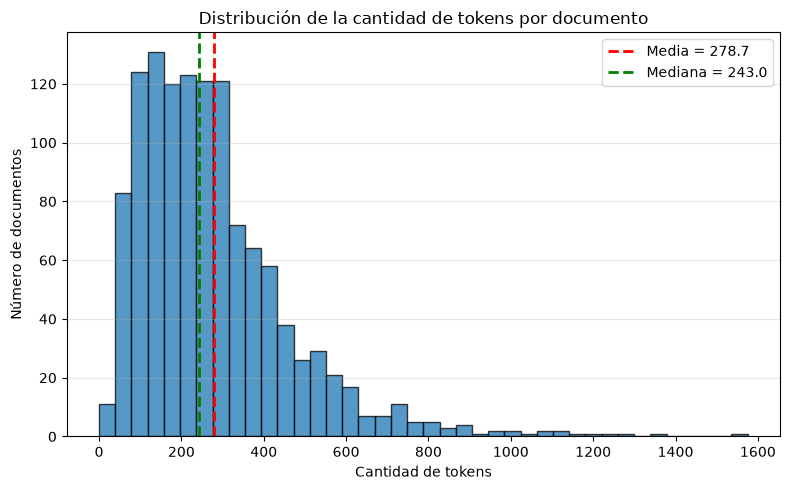

In [13]:
# Histograma de la cantidad de tokens por documento

media = df["token_count"].mean()
mediana = df["token_count"].median()

plt.figure(figsize=(8,5))

plt.hist(
    df["token_count"],
    bins="auto",
    edgecolor="black",
    alpha=0.75
)

plt.axvline(media,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Media = {media:.1f}")

plt.axvline(mediana,
            color="green",
            linestyle="--",
            linewidth=2,
            label=f"Mediana = {mediana:.1f}")

plt.title("Distribución de la cantidad de tokens por documento")
plt.xlabel("Cantidad de tokens")
plt.ylabel("Número de documentos")
plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


/var/folders/c2/7hv2k_zd35380q4h8tgsvc3h0000gn/T/ipykernel_83101/1749766272.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["token_count"], vert=False)


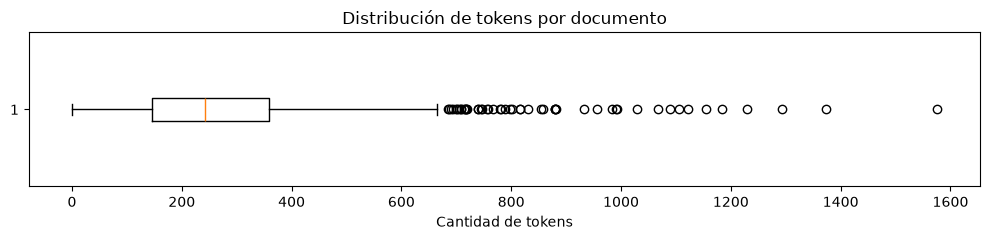

In [14]:
plt.figure(figsize=(10,2.5))

plt.boxplot(df["token_count"], vert=False)

plt.title("Distribución de tokens por documento")
plt.xlabel("Cantidad de tokens")

plt.tight_layout()
plt.show()

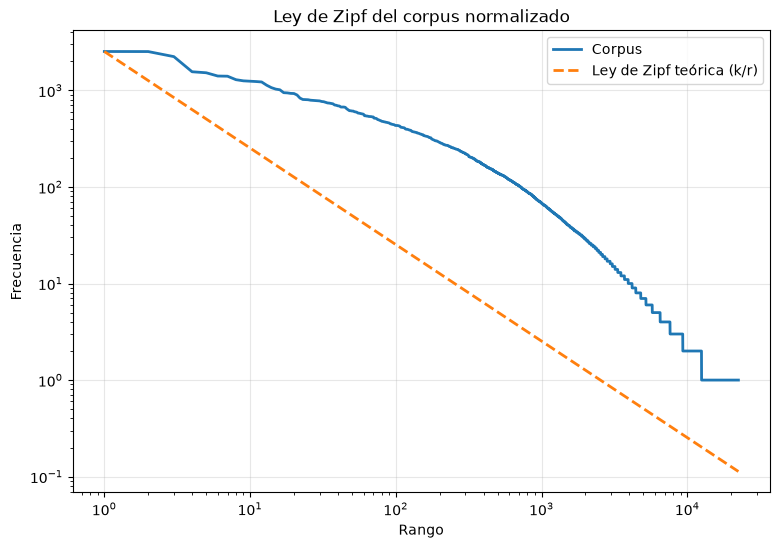

Pendiente aproximada: -1.374


In [15]:

# Ley de Zipf

freq_sorted = np.array(sorted(freq.values(), reverse=True))
ranks = np.arange(1, len(freq_sorted) + 1)

# Pendiente aproximada
zipf_slope, zipf_intercept = np.polyfit(np.log10(ranks), np.log10(freq_sorted), 1)

# Curva teórica
zipf_theoretical = freq_sorted[0] / ranks

plt.figure(figsize=(9,6))

plt.plot(ranks, freq_sorted,
         label="Corpus",
         linewidth=2)

plt.plot(ranks, zipf_theoretical,
         "--",
         label="Ley de Zipf teórica (k/r)",
         linewidth=2)

plt.xscale("log")
plt.yscale("log")

plt.title("Ley de Zipf del corpus normalizado")
plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

print(f"Pendiente aproximada: {zipf_slope:.3f}")


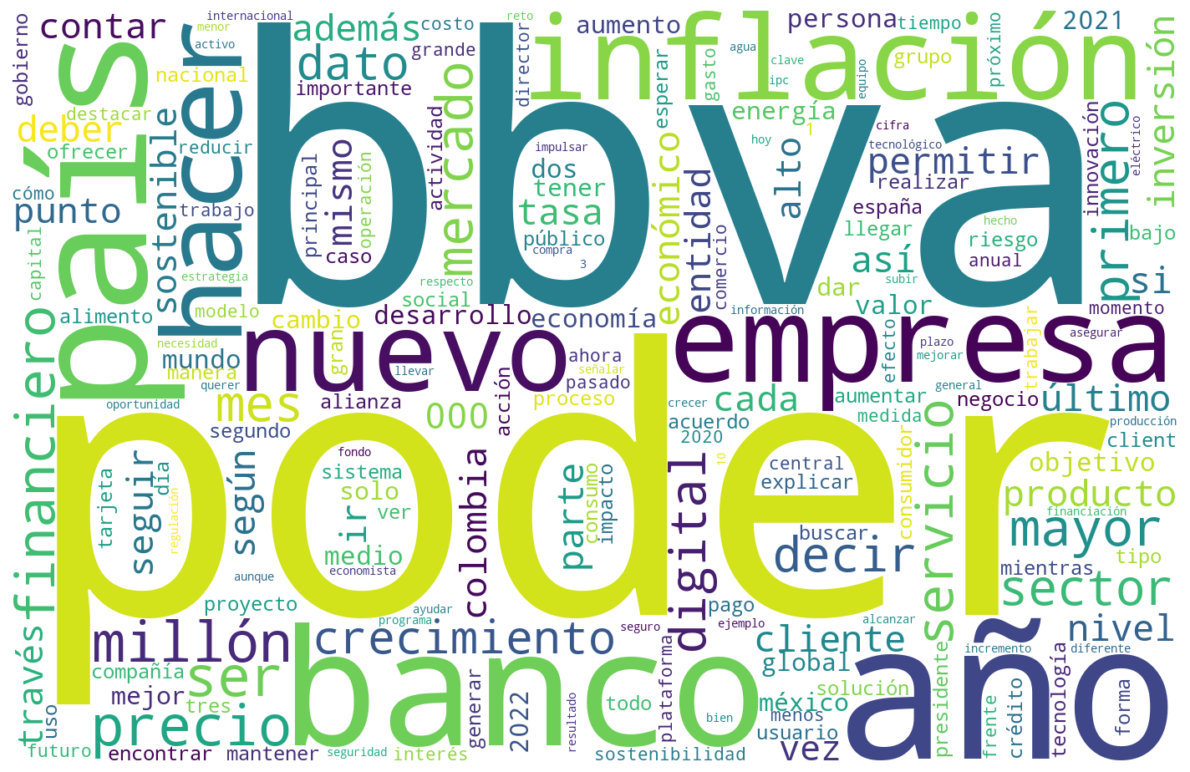

In [16]:


# Nube de palabras

wc = WordCloud(width=1400, height=900, background_color="white").generate_from_frequencies(freq)

plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.tight_layout()
plt.show()


In [17]:

# Comparación por categoría
# Se comparan las 10 palabras más frecuentes de dos categorías


def top_words_by_category(category, n=10):
    """
    Devuelve las n palabras más frecuentes de una categoría.
    
    Parámetros:
        category (str): Nombre de la categoría.
        n (int): Número de palabras a mostrar.
    
    Retorna:
        DataFrame con las palabras y su frecuencia.
    """
    
    # Obtener todos los tokens de la categoría seleccionada
    tokens_categoria = flatten(df.loc[df["Type"] == category, "tokens"])

    # Contar la frecuencia de cada palabra
    frecuencia = Counter(tokens_categoria)

    # Crear el DataFrame con las n palabras más frecuentes
    return pd.DataFrame(
        frecuencia.most_common(n),
        columns=["Palabra", "Frecuencia"]
    )


# Categorías a comparar
categorias = ["Innovacion", "Macroeconomia","Sostenibilidad","Alianzas"]

# Mostrar el Top 10 de cada categoría
for categoria in categorias:
    print(f"\nTop 10 palabras más frecuentes - {categoria}")
    display(top_words_by_category(categoria))


Top 10 palabras más frecuentes - Innovacion


,Palabra,Frecuencia
0,bbva,1120
1,poder,588
2,banco,415
3,cliente,398
4,digital,387
5,nuevo,370
6,empresa,362
7,dato,352
8,permitir,314
9,financiero,309



Top 10 palabras más frecuentes - Macroeconomia


,Palabra,Frecuencia
0,inflación,1331
1,precio,1016
2,año,1003
3,poder,679
4,bbva,547
5,mes,530
6,mayor,523
7,tasa,516
8,país,456
9,aumento,421



Top 10 palabras más frecuentes - Sostenibilidad


,Palabra,Frecuencia
0,bbva,481
1,poder,436
2,sostenible,387
3,energía,374
4,agua,274
5,año,249
6,sostenibilidad,231
7,eléctrico,231
8,objetivo,223
9,empresa,205



Top 10 palabras más frecuentes - Alianzas


,Palabra,Frecuencia
0,alianza,427
1,país,369
2,poder,341
3,colombia,292
4,millón,274
5,año,261
6,nuevo,256
7,empresa,237
8,hacer,203
9,mercado,193


**Comparación por categoría.**  
La comparación de categorías muestra que el vocabulario cambia según el tema. En `Innovacion` aparecen palabras como `cliente`, `digital`, `financiero` y `plataforma`, mientras que en `Macroeconomia` predominan `inflación`, `precio`, `tasa`, `año` y `país`. Esto confirma que el corpus está bien organizado por temática y que el preprocesamiento conserva diferencias útiles para el análisis.

### Lectura rápida de los resultados

- La distribución de tokens por documento suele ser asimétrica: algunos documentos son mucho más largos que otros.  
- La curva de Zipf en escala log-log debería verse aproximadamente lineal y descendente.  
- En las categorías, el vocabulario cambia según el tema: por ejemplo, en `Innovacion` suelen dominar términos tecnológicos y de cliente, mientras que en `Macroeconomia` aparecen palabras de inflación, precios, tasas y crecimiento.

### 6. Análisis de resultados

**Ley de Zipf.**  
La curva obtenida en escala log-log muestra un comportamiento cercano al teórico. La pendiente aproximada fue de **-1.374**, por lo que la distribución conserva la forma descendente esperada en un corpus natural. 

La diferencia con la curva ideal se explica porque el corpus no es completamente homogéneo: está compuesto por noticias de negocios y economía, con muchas repeticiones de nombres propios, instituciones y términos muy frecuentes como `bbva`, `banco`, `inflación` o `poder`.

### Reducción del vocabulario
La normalización sí tuvo un efecto claro. El vocabulario pasó de **32,606 tipos** en la tokenización inicial a **22,398 tipos** después de la lematización, es decir, una reducción total de **31.31%** respecto al vocabulario inicial. Por pasos, la reducción del vocabulario fue aproximadamente:  
- **Minúsculas:** de 32,606 a 29,571 tipos (**9.31%**).  
- **Eliminar puntuación:** de 29,571 a 29,530 tipos (**0.14%**).  
- **Eliminar stopwords:** de 29,530 a 29,315 tipos (**0.73%**).  
- **Lematización:** de 29,315 a 22,398 tipos (**23.59%**).  

El paso con mayor impacto fue la **lematización**, porque unifica distintas formas flexionadas de una misma palabra en un solo lema.

### Efecto de eliminar stopwords
Quitar stopwords redujo bastante la cantidad total de tokens y ayudó a concentrar el análisis en palabras con más contenido semántico. 

En este corpus, esa limpieza no destruye el sentido general de las noticias porque la temática principal sigue estando marcada por sustantivos y nombres propios. 

Sin embargo, siempre hay que revisar el contexto ya que algunas palabras muy frecuentes pueden aportar mucha informacion 


----

-----

LABORATORIO 2 - REPRESENTACIONES BÁSICAS DE TEXTO

7. Preparación para el Laboratorio 2
8. Bag of Words
9. Vectores de conteo y dispersión
10. N-gramas
11. TF-IDF
12. Similitud coseno
13. Análisis de resultados del Laboratorio 2
14. Conclusiones

### Preparación para las representaciones de texto

Del Laboratorio 1 ya se dispone del corpus cargado y de una columna `tokens`
que contiene cada noticia después de aplicar tokenización, conversión a
minúsculas, eliminación de puntuación, eliminación de stopwords y
lematización.

Para este laboratorio se creó la columna `texto_normalizado`, que reconstruye
cada documento uniendo nuevamente sus tokens mediante espacios. Esta
representación será utilizada como entrada para `CountVectorizer` y
`TfidfVectorizer`.

In [18]:


# Reconstruir cada documento normalizado como texto.
# En el Laboratorio 1 cada documento quedó representado
# como una lista de tokens. Para usar CountVectorizer y
# TfidfVectorizer unimos nuevamente los tokens con espacios.

df["texto_normalizado"] = df["tokens"].apply(lambda tokens: " ".join(tokens))

# Verificar el resultado
df[["news", "texto_normalizado", "Type"]].head()

,news,texto_normalizado,Type
0,Durante el foro La banca articulador empresari...,foro banca articulador empresarial desarrollo ...,Otra
1,El regulador de valores de China dijo el domin...,regulador valor chino decir domingo buscar coo...,Regulaciones
2,En una industria históricamente masculina como...,industria históricamente masculino aviación vi...,Alianzas
3,Con el dato de marzo el IPC interanual encaden...,dato marzo ipc interanual encadenar decimoquin...,Macroeconomia
4,Ayer en Cartagena se dio inicio a la versión n...,ayer cartagena dar inicio versión número 56 co...,Otra


In [19]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [20]:

# Bag of Words (BoW)


vectorizer_bow = CountVectorizer()

X_bow = vectorizer_bow.fit_transform(df["texto_normalizado"])

vocabulario_bow = vectorizer_bow.get_feature_names_out()

print("Forma de la matriz BoW:", X_bow.shape)
print("Número de documentos:", X_bow.shape[0])
print("Tamaño del vocabulario:", X_bow.shape[1])

Forma de la matriz BoW: (1217, 21911)
Número de documentos: 1217
Tamaño del vocabulario: 21911


In [21]:
# Mostrar información básica de la representación Bag of Words

print(f"Número de documentos: {X_bow.shape[0]}")
print(f"Tamaño del vocabulario: {X_bow.shape[1]}")
print(f"Forma de la matriz BoW: {X_bow.shape}")

# Mostrar algunas palabras del vocabulario
print("\nPrimeras 20 palabras del vocabulario:")
print(vocabulario_bow[:20])

Número de documentos: 1217
Tamaño del vocabulario: 21911
Forma de la matriz BoW: (1217, 21911)

Primeras 20 palabras del vocabulario:
['00' '000' '000a' '000mentre' '001' '002' '003' '004' '005' '0052020smv'
 '006' '007' '00750' '008' '0089' '009' '00audio' '01' '010' '0100']


### Interpretación de Bag of Words

La representación Bag of Words transforma cada documento en un vector de
conteos. Cada columna representa una palabra del vocabulario y cada fila
representa un documento del corpus. El valor almacenado en una celda indica
cuántas veces aparece esa palabra en ese documento.

La principal ventaja de esta representación es que convierte el texto en
información numérica que puede ser utilizada por algoritmos de aprendizaje
automático. Además, permite identificar fácilmente qué palabras aparecen y
con qué frecuencia.

Sin embargo, Bag of Words pierde información importante del lenguaje. No
conserva el orden de las palabras, la estructura gramatical ni el contexto.
Por ejemplo, dos documentos que contienen las mismas palabras con un orden
diferente pueden obtener representaciones muy similares aunque su significado
no sea exactamente el mismo.

A cambio de esta pérdida de información, se obtiene una representación simple,
eficiente y fácil de utilizar para tareas como clasificación de documentos.

---

In [22]:

# 9. Vectores de conteo y dispersión


# Número total de celdas de la matriz
total_celdas = X_bow.shape[0] * X_bow.shape[1]

# X_bow.nnz indica cuántas celdas tienen un valor distinto de cero
celdas_no_cero = X_bow.nnz

# Las demás celdas contienen cero
celdas_cero = total_celdas - celdas_no_cero

# Porcentaje de dispersión (sparsity)
sparsity = (celdas_cero / total_celdas) * 100

print(f"Total de celdas: {total_celdas:,}")
print(f"Celdas distintas de cero: {celdas_no_cero:,}")
print(f"Celdas iguales a cero: {celdas_cero:,}")
print(f"Dispersión de la matriz: {sparsity:.2f}%")

Total de celdas: 26,665,687
Celdas distintas de cero: 228,291
Celdas iguales a cero: 26,437,396
Dispersión de la matriz: 99.14%


In [23]:

# Dispersión con diferentes tamaños de vocabulario


# Tamaños de vocabulario solicitados en el laboratorio
vocab_sizes = [100, 500, 1000, 5000]

resultados_sparsity = []

for vocab_size in vocab_sizes:

    # Crear Bag of Words limitado a las palabras
    # más frecuentes del corpus
    vectorizer = CountVectorizer(max_features=vocab_size)

    X_temp = vectorizer.fit_transform(df["texto_normalizado"])

    # Número total de celdas
    total = X_temp.shape[0] * X_temp.shape[1]

    # Número de celdas distintas de cero
    no_cero = X_temp.nnz

    # Calcular porcentaje de ceros
    sparsity_temp = ((total - no_cero) / total) * 100

    resultados_sparsity.append({
        "Vocabulario": X_temp.shape[1],
        "Dispersión (%)": sparsity_temp
    })


# Convertir resultados en DataFrame
df_sparsity = pd.DataFrame(resultados_sparsity)

df_sparsity

,Vocabulario,Dispersión (%)
0,100,69.829910
1,500,83.830567
2,1000,89.029417
3,5000,96.728710


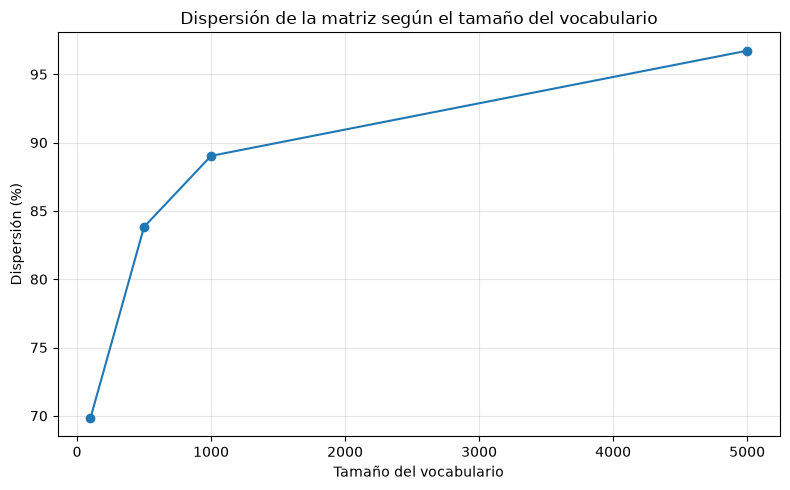

In [24]:
# Gráfica de dispersión según el tamaño del vocabulario

plt.figure(figsize=(8,5))

plt.plot(
    df_sparsity["Vocabulario"],
    df_sparsity["Dispersión (%)"],
    marker="o"
)

plt.title("Dispersión de la matriz según el tamaño del vocabulario")
plt.xlabel("Tamaño del vocabulario")
plt.ylabel("Dispersión (%)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretación de la dispersión

Los resultados muestran que la dispersión aumenta conforme se incrementa el tamaño del vocabulario. Con un vocabulario limitado a 100 palabras, el 69.83% de las celdas de la matriz son cero. Al aumentar a 500 palabras, la dispersión sube a 83.83%; con 1,000 palabras alcanza 89.03%, y con 5,000 palabras llega a 96.73%. Al utilizar el vocabulario completo, la matriz presenta una dispersión de 99.14%.

Esto ocurre porque cada documento utiliza solamente una pequeña parte del vocabulario total. Las palabras más frecuentes tienden a aparecer en muchos documentos, por lo que una matriz limitada a 100 términos contiene proporcionalmente más valores distintos de cero. Sin embargo, al incorporar miles de términos menos frecuentes, se agregan muchas columnas correspondientes a palabras que aparecen solamente en algunos documentos, aumentando así la cantidad de ceros.

Una mayor dispersión también tiene implicaciones de almacenamiento y cómputo. Si la matriz se almacenara de forma densa, sería necesario reservar memoria para millones de valores iguales a cero. Por esta razón, las representaciones de texto suelen utilizar estructuras de matrices dispersas que almacenan principalmente los valores distintos de cero.

In [25]:
# Verificar el tipo de matriz generado por CountVectorizer

print("Tipo de matriz:", type(X_bow))
print("Formato:", X_bow.getformat())

Tipo de matriz: <class 'scipy.sparse._csr.csr_matrix'>
Formato: csr


### Matrices dispersas (Sparse Matrices)

Una matriz dispersa es una matriz en la que la mayoría de sus elementos son cero. Este tipo de matriz aparece frecuentemente en NLP porque cada documento contiene solamente una pequeña parte de todas las palabras disponibles en el vocabulario.

Almacenar estas matrices como matrices densas sería poco eficiente, ya que se utilizaría memoria para guardar una gran cantidad de ceros. Por esta razón se utilizan estructuras especializadas para matrices dispersas.

Una de ellas es **CSR (Compressed Sparse Row)**. Este formato almacena principalmente los valores distintos de cero junto con información que permite identificar su posición dentro de la matriz. De esta manera se reduce considerablemente el uso de memoria y se pueden realizar operaciones matemáticas de manera más eficiente.

`CountVectorizer` de scikit-learn devuelve precisamente una matriz dispersa, lo cual resulta conveniente para representaciones Bag of Words con vocabularios grandes.

---

## 10. N-gramas

Un n-grama es una secuencia de `n` elementos consecutivos de un texto. En este apartado se comparan dos representaciones:

- **Unigramas (n=1):** cada característica corresponde a una palabra individual.
- **Bigramas (n=2):** cada característica corresponde a una secuencia de dos palabras consecutivas.

Los bigramas permiten conservar parte del orden local de las palabras, por lo que pueden representar expresiones que un modelo basado únicamente en palabras individuales no captura.

In [26]:

# 10. N-gramas: unigramas y bigramas


# Representación con unigramas
vectorizer_unigram = CountVectorizer(ngram_range=(1, 1))
X_unigram = vectorizer_unigram.fit_transform(df["texto_normalizado"])

# Representación con bigramas
vectorizer_bigram = CountVectorizer(ngram_range=(2, 2))
X_bigram = vectorizer_bigram.fit_transform(df["texto_normalizado"])

# Obtener los vocabularios
vocab_unigram = vectorizer_unigram.get_feature_names_out()
vocab_bigram = vectorizer_bigram.get_feature_names_out()

# Mostrar resultados
print("Número de documentos:", X_unigram.shape[0])

print("\nUNIGRAMAS")
print("Forma de la matriz:", X_unigram.shape)
print("Tamaño del vocabulario:", len(vocab_unigram))

print("\nBIGRAMAS")
print("Forma de la matriz:", X_bigram.shape)
print("Tamaño del vocabulario:", len(vocab_bigram))

Número de documentos: 1217

UNIGRAMAS
Forma de la matriz: (1217, 21911)
Tamaño del vocabulario: 21911

BIGRAMAS
Forma de la matriz: (1217, 223876)
Tamaño del vocabulario: 223876


In [27]:

# 15 bigramas más frecuentes del corpus


# Sumar la cantidad de veces que aparece cada bigrama
# en todos los documentos del corpus
frecuencias_bigramas = np.asarray(
    X_bigram.sum(axis=0)
).ravel()

# Crear DataFrame con bigramas y frecuencias
df_bigramas = pd.DataFrame({
    "Bigrama": vocab_bigram,
    "Frecuencia": frecuencias_bigramas
})

# Ordenar de mayor a menor y seleccionar los 15 más frecuentes
top15_bigramas = (
    df_bigramas
    .sort_values("Frecuencia", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

top15_bigramas

,Bigrama,Frecuencia
0,banco central,224
1,bbva research,212
2,poder ser,208
3,cada vez,197
4,tasa interés,192
5,000 millón,189
6,entidad financiero,179
7,cambio climático,166
8,bbva méxico,155
9,punto básico,142


In [28]:

# Comparación de dispersión: unigramas vs. bigramas


def calcular_sparsity(matriz):
    total_celdas = matriz.shape[0] * matriz.shape[1]
    celdas_no_cero = matriz.nnz
    celdas_cero = total_celdas - celdas_no_cero

    return (celdas_cero / total_celdas) * 100


sparsity_unigram = calcular_sparsity(X_unigram)
sparsity_bigram = calcular_sparsity(X_bigram)

comparacion_ngramas = pd.DataFrame({
    "Representación": ["Unigramas", "Bigramas"],
    "Tamaño vocabulario": [
        X_unigram.shape[1],
        X_bigram.shape[1]
    ],
    "Dispersión (%)": [
        sparsity_unigram,
        sparsity_bigram
    ]
})

comparacion_ngramas

,Representación,Tamaño vocabulario,Dispersión (%)
0,Unigramas,21911,99.143877
1,Bigramas,223876,99.882660


### Análisis de unigramas y bigramas

La representación mediante unigramas produjo un vocabulario de **21,911 términos**, mientras que la representación mediante bigramas generó **223,876 combinaciones diferentes**. Esto muestra que al considerar secuencias de dos palabras el espacio de características aumenta considerablemente.

Los bigramas permiten capturar información que los unigramas no representan por sí solos. Por ejemplo, entre los bigramas más frecuentes aparecen expresiones como **"banco central"**, **"tasa interés"**, **"cambio climático"**, **"entidad financiero"**, **"precio consumidor"** y **"bbva research"**. Cada una representa un concepto más específico que sus palabras individuales. Por ejemplo, las palabras "banco" y "central" por separado tienen significados más generales, mientras que "banco central" identifica directamente una institución relacionada con política monetaria.

Esta capacidad constituye una ventaja de los bigramas frente a una Bolsa de Palabras basada únicamente en unigramas, ya que conservan parcialmente el orden local de las palabras y permiten identificar expresiones formadas por varios términos. Los trigramas pueden conservar todavía más contexto al representar secuencias de tres palabras.

Sin embargo, esta ventaja tiene un costo. El vocabulario aumentó de **21,911 unigramas a 223,876 bigramas**, por lo que la representación requiere un espacio de características mucho mayor. Además, muchas combinaciones aparecen solamente en pocos documentos, haciendo que la matriz sea más dispersa.

Esto se observa en la dispersión calculada: la matriz de unigramas presenta **99.14%** de valores iguales a cero, mientras que con bigramas la dispersión aumenta hasta **99.88%**. Por lo tanto, utilizar n-gramas permite representar más contexto, pero aumenta considerablemente la dimensionalidad y la dispersión de los datos.

También se observa que no todos los bigramas frecuentes aportan el mismo nivel de información. Expresiones como **"poder ser"**, **"cada vez"** o **"si bien"** son frecuentes, pero son menos específicas respecto al tema de una noticia. Esto indica que utilizar bigramas aumenta la cantidad de información contextual disponible, aunque puede ser necesario aplicar posteriormente técnicas de selección de características para conservar las combinaciones más relevantes.

---

## 11. TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) es una representación que asigna un peso a cada término de acuerdo con su importancia dentro de un documento y su frecuencia en el corpus.

A diferencia de Bag of Words, TF-IDF no considera únicamente cuántas veces aparece una palabra. También toma en cuenta en cuántos documentos aparece. De esta manera, las palabras muy frecuentes en todo el corpus reciben menor importancia, mientras que las palabras que son frecuentes dentro de un documento pero poco comunes en el resto del corpus reciben un peso mayor.

In [29]:

# 11. TF-IDF


# Crear el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer()

# Construir la matriz TF-IDF
X_tfidf = tfidf_vectorizer.fit_transform(df["texto_normalizado"])

# Obtener el vocabulario
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print("Forma de la matriz TF-IDF:", X_tfidf.shape)
print("Número de documentos:", X_tfidf.shape[0])
print("Tamaño del vocabulario:", X_tfidf.shape[1])
print("Tipo de matriz:", type(X_tfidf))

Forma de la matriz TF-IDF: (1217, 21911)
Número de documentos: 1217
Tamaño del vocabulario: 21911
Tipo de matriz: <class 'scipy.sparse._csr.csr_matrix'>


In [30]:

# Seleccionar 3 documentos de categorías diferentes

categorias_seleccionadas = [
    "Macroeconomia",
    "Innovacion",
    "Sostenibilidad"
]

documentos_seleccionados = []

for categoria in categorias_seleccionadas:
    
    # Obtener el índice del primer documento de la categoría
    indice = df[df["Type"] == categoria].index[0]
    
    documentos_seleccionados.append(indice)

print("Documentos seleccionados:")

for indice in documentos_seleccionados:
    print(
        f"Índice: {indice} | "
        f"Categoría: {df.loc[indice, 'Type']}"
    )

Documentos seleccionados:
Índice: 3 | Categoría: Macroeconomia
Índice: 7 | Categoría: Innovacion
Índice: 12 | Categoría: Sostenibilidad


In [31]:


# Obtener los términos con mayor TF-IDF de un documento


def top_tfidf_documento(indice, n=10):
    
    # Obtener el vector TF-IDF del documento
    vector = X_tfidf[indice]
    
    # Convertir los valores a un arreglo
    valores = vector.toarray().flatten()
    
    # Obtener los índices de los términos con mayor TF-IDF
    top_indices = valores.argsort()[::-1][:n]
    
    # Crear DataFrame con término y puntaje
    resultado = pd.DataFrame({
        "Palabra": vocab_tfidf[top_indices],
        "TF-IDF": valores[top_indices]
    })
    
    return resultado


# Mostrar los resultados de los tres documentos
for indice in documentos_seleccionados:
    
    print("\n" + "=" * 50)
    print(f"Documento {indice}")
    print(f"Categoría: {df.loc[indice, 'Type']}")
    print("=" * 50)
    
    display(top_tfidf_documento(indice))


Documento 3
Categoría: Macroeconomia


,Palabra,TF-IDF
0,marzo,0.260178
1,ipc,0.240543
2,tasa,0.226981
3,mensual,0.191977
4,situar,0.162150
5,95,0.160429
6,ipca,0.154605
7,punto,0.150476
8,pescado,0.139310
9,interanual,0.133306



Documento 7
Categoría: Innovacion


,Palabra,TF-IDF
0,agile,0.424711
1,nacho,0.332413
2,podcast,0.263397
3,alumno,0.255956
4,introducir,0.208065
5,legal,0.187161
6,nachir,0.166206
7,thinktank,0.166206
8,rrhh,0.166206
9,talentboost,0.166206



Documento 12
Categoría: Sostenibilidad


,Palabra,TF-IDF
0,agua,0.528942
1,lluvia,0.240075
2,escuela,0.235788
3,scall,0.226103
4,infierno,0.163945
5,fundación,0.139144
6,sostenible,0.133323
7,litro,0.133058
8,sistema,0.113486
9,educativo,0.113428


In [32]:

# Obtener las palabras más frecuentes por conteo simple


def top_conteo_documento(indice, n=10):
    
    # Obtener tokens del documento
    tokens = df.loc[indice, "tokens"]
    
    # Contar las palabras
    conteos = Counter(tokens)
    
    # Obtener las n más frecuentes
    resultado = pd.DataFrame(
        conteos.most_common(n),
        columns=["Palabra", "Frecuencia"]
    )
    
    return resultado


for indice in documentos_seleccionados:
    
    print("\n" + "=" * 50)
    print(f"Documento {indice}")
    print(f"Categoría: {df.loc[indice, 'Type']}")
    print("=" * 50)
    
    print("\nTop 10 por TF-IDF")
    display(top_tfidf_documento(indice))
    
    print("Top 10 por conteo simple")
    display(top_conteo_documento(indice))


Documento 3
Categoría: Macroeconomia

Top 10 por TF-IDF


,Palabra,TF-IDF
0,marzo,0.260178
1,ipc,0.240543
2,tasa,0.226981
3,mensual,0.191977
4,situar,0.162150
5,95,0.160429
6,ipca,0.154605
7,punto,0.150476
8,pescado,0.139310
9,interanual,0.133306


Top 10 por conteo simple


,Palabra,Frecuencia
0,tasa,8
1,marzo,7
2,ipc,7
3,punto,6
4,mensual,5
5,situar,4
6,precio,4
7,interanual,3
8,inflación,3
9,febrero,3



Documento 7
Categoría: Innovacion

Top 10 por TF-IDF


...

,Palabra,Frecuencia
0,podcast,3
1,agile,3
2,nacho,2
3,varios,2
4,introducir,2
5,alumno,2
6,sector,2
7,legal,2
8,placer,1
9,entrevistar,1



Documento 12
Categoría: Sostenibilidad

Top 10 por TF-IDF


,Palabra,TF-IDF
0,agua,0.528942
1,lluvia,0.240075
2,escuela,0.235788
3,scall,0.226103
4,infierno,0.163945
5,fundación,0.139144
6,sostenible,0.133323
7,litro,0.133058
8,sistema,0.113486
9,educativo,0.113428


Top 10 por conteo simple


,Palabra,Frecuencia
0,agua,17
1,bbva,7
2,sostenible,6
3,escuela,6
4,sistema,5
5,lluvia,5
6,comunidad,4
7,scall,4
8,fundación,4
9,poder,4


### Análisis de los resultados TF-IDF

Para analizar TF-IDF se seleccionaron tres documentos pertenecientes a categorías diferentes: **Macroeconomía (documento 3)**, **Innovación (documento 7)** y **Sostenibilidad (documento 12)**.

#### Documento 3 - Macroeconomía

Entre los términos con mayor TF-IDF aparecen **marzo, IPC, tasa, mensual, IPCA e interanual**. Estas palabras están directamente relacionadas con indicadores económicos y con la medición de precios e inflación, por lo que representan adecuadamente el contenido del artículo.

Al comparar estos resultados con el conteo simple se observa bastante coincidencia. Por ejemplo, **tasa, marzo, IPC, punto, mensual, situar e interanual** aparecen en ambas listas. Sin embargo, el orden cambia. `tasa` es la palabra más frecuente, con 8 apariciones, pero `marzo` obtiene el mayor TF-IDF.

Esto ocurre porque TF-IDF no considera únicamente cuántas veces aparece una palabra dentro del documento, sino también qué tan común es esa palabra en el resto del corpus. Una palabra puede aparecer menos veces que otra y aun así obtener mayor TF-IDF si es menos frecuente en las demás noticias.

#### Documento 7 - Innovación

Los términos con mayor TF-IDF incluyen **agile, nacho, podcast, alumno, introducir, legal, thinktank, RRHH y talentboost**. Estos términos permiten identificar temas y entidades bastante particulares del artículo.

En el conteo simple, `podcast` y `agile` aparecen 3 veces, mientras que términos como `nacho`, `introducir`, `alumno` y `legal` aparecen 2 veces. Aunque varias palabras coinciden entre ambas representaciones, TF-IDF otorga importancia adicional a términos como **thinktank, RRHH y talentboost**, aun cuando no se encuentran entre las palabras con mayor frecuencia simple.

Esto muestra una de las principales características de TF-IDF: un término no necesita aparecer muchas veces para ser relevante. Si aparece en pocos documentos del corpus, su componente IDF puede aumentar su peso y convertirlo en una característica importante de una noticia específica.

#### Documento 12 - Sostenibilidad

En este documento, **agua** obtiene claramente el mayor valor TF-IDF y también es la palabra más frecuente, con 17 apariciones. Esto indica que es un término central para el contenido del artículo.

También aparecen con valores altos de TF-IDF términos como **lluvia, escuela, scall, fundación, sostenible, litro, sistema y educativo**. En el conteo simple encontramos varias coincidencias, como `agua`, `sostenible`, `escuela`, `sistema`, `lluvia`, `scall` y `fundación`.

Sin embargo, palabras como `bbva`, que aparece 7 veces y ocupa el segundo lugar por frecuencia, no se encuentra entre los diez términos con mayor TF-IDF. Esto puede explicarse porque **BBVA aparece en muchas noticias del corpus**, por lo que su capacidad para distinguir este documento particular es menor. En cambio, palabras más específicas del artículo reciben un peso TF-IDF superior.

### Comparación entre conteo simple y TF-IDF

Los resultados muestran que existe cierta coincidencia entre las palabras más frecuentes y las palabras con mayor TF-IDF, pero las listas no son idénticas.

El **conteo simple** solamente mide cuántas veces aparece una palabra dentro de un documento. Por esta razón, puede asignar mucha importancia a palabras que son frecuentes tanto en esa noticia como en muchas otras noticias del corpus.

TF-IDF combina dos componentes:

- **TF (Term Frequency):** mide la frecuencia de un término dentro del documento.
- **IDF (Inverse Document Frequency):** reduce el peso de términos presentes en muchos documentos y aumenta relativamente la importancia de términos menos comunes en el corpus.

Por esta razón, TF-IDF penaliza palabras muy comunes en la colección y favorece términos que son frecuentes dentro de un documento pero poco comunes en los demás. Esto permite identificar palabras que caracterizan mejor el contenido particular de cada noticia.

----

## 12. Similitud entre documentos - Similitud coseno

La similitud coseno permite medir qué tan parecidos son dos documentos comparando la orientación de sus vectores.

En este apartado se utilizan los vectores TF-IDF obtenidos anteriormente. Un valor de similitud cercano a **1** indica que dos documentos tienen representaciones muy similares, mientras que un valor cercano a **0** indica que comparten poca información en términos de sus características TF-IDF.

El objetivo es evaluar si las noticias que presentan mayor similitud textual también tienden a pertenecer a la misma categoría.

In [33]:

# Documento de referencia


indice_referencia = 3

print("Documento de referencia")
print("Índice:", indice_referencia)
print("Categoría:", df.loc[indice_referencia, "Type"])

print("\nTexto original:")
print(df.loc[indice_referencia, "news"][:500], "...")

Documento de referencia
Índice: 3
Categoría: Macroeconomia

Texto original:
Con el dato de marzo el IPC interanual encadena su decimoquinta tasa positiva consecutiva. La inflación publicada por el INE se ha mantenido igual respecto al avance del 30 de marzo y se sitúa 22 puntos por encima del dato de febrero que ascendió al 76.De esos 22 puntos de diferencia la mayor parte la colocó el grupo de la vivienda 09 puntos por la subida de la electricidad y el del transporte 07 puntos por el alza de los carburantes. También impulsaron el IPC de marzo el aumento de los precios  ...


In [34]:

# Similitud coseno entre el documento de referencia
# y todos los documentos del corpus


similitudes = cosine_similarity(
    X_tfidf[indice_referencia],
    X_tfidf
).flatten()

print("Número de similitudes calculadas:", len(similitudes))

Número de similitudes calculadas: 1217


In [35]:

# Encontrar los 5 documentos más similares


# Ordenar índices de mayor a menor similitud
indices_ordenados = similitudes.argsort()[::-1]

# Excluir el documento de referencia
indices_similares = [
    i for i in indices_ordenados
    if i != indice_referencia
][:5]

# Construir tabla de resultados
resultados_similares = pd.DataFrame({
    "Índice": indices_similares,
    "Categoría": [
        df.loc[i, "Type"]
        for i in indices_similares
    ],
    "Similitud coseno": [
        similitudes[i]
        for i in indices_similares
    ]
})

resultados_similares

,Índice,Categoría,Similitud coseno
0,1211,Macroeconomia,0.404425
1,1204,Macroeconomia,0.285978
2,834,Macroeconomia,0.237040
3,121,Macroeconomia,0.233441
4,240,Macroeconomia,0.222911


In [36]:
# Comparar categorías con el documento de referencia

categoria_referencia = df.loc[indice_referencia, "Type"]

resultados_similares["Misma categoría"] = (
    resultados_similares["Categoría"] == categoria_referencia
)

resultados_similares

,Índice,Categoría,Similitud coseno,Misma categoría
0,1211,Macroeconomia,0.404425,True
1,1204,Macroeconomia,0.285978,True
2,834,Macroeconomia,0.237040,True
3,121,Macroeconomia,0.233441,True
4,240,Macroeconomia,0.222911,True


In [37]:

# Matriz de similitud coseno de todo el corpus


matriz_similitud = cosine_similarity(X_tfidf)

print("Forma de la matriz de similitud:", matriz_similitud.shape)

Forma de la matriz de similitud: (1217, 1217)


In [38]:

# Similitud promedio:
# misma categoría vs. categorías diferentes


categorias = df["Type"].to_numpy()

similitudes_misma_categoria = []
similitudes_distinta_categoria = []

# Recorremos solamente la parte superior de la matriz
# para no contar cada pareja dos veces.
for i in range(len(df)):
    for j in range(i + 1, len(df)):

        similitud = matriz_similitud[i, j]

        if categorias[i] == categorias[j]:
            similitudes_misma_categoria.append(similitud)
        else:
            similitudes_distinta_categoria.append(similitud)

promedio_misma = np.mean(similitudes_misma_categoria)
promedio_distinta = np.mean(similitudes_distinta_categoria)

comparacion_similitud = pd.DataFrame({
    "Comparación": [
        "Misma categoría",
        "Categorías diferentes"
    ],
    "Similitud coseno promedio": [
        promedio_misma,
        promedio_distinta
    ]
})

comparacion_similitud

,Comparación,Similitud coseno promedio
0,Misma categoría,0.075198
1,Categorías diferentes,0.040091


### ¿Por qué utilizar similitud coseno?

La similitud coseno resulta adecuada para comparar documentos porque se concentra principalmente en la **orientación de los vectores** y no en su magnitud.

Dos noticias pueden tratar sobre el mismo tema pero tener longitudes muy diferentes. Una noticia extensa tendrá normalmente más términos y puede generar un vector con una magnitud mayor que una noticia corta. Una distancia como la euclidiana puede verse afectada por esta diferencia de magnitud.

La similitud coseno, en cambio, permite determinar si ambos documentos presentan una distribución similar de términos relevantes aunque tengan longitudes diferentes. Por esta razón es ampliamente utilizada para comparar documentos representados mediante vectores como TF-IDF.

### Análisis de la similitud entre documentos

Se seleccionó como referencia el **documento 3**, perteneciente a la categoría **Macroeconomía**. Al calcular la similitud coseno utilizando las representaciones TF-IDF, los cinco documentos más similares encontrados pertenecen también a la categoría Macroeconomía.

Las similitudes obtenidas para estos documentos fueron aproximadamente **0.4044, 0.2860, 0.2370, 0.2334 y 0.2229**. Aunque los valores no son cercanos a 1, son los documentos que presentan una orientación más similar al documento de referencia dentro del espacio TF-IDF.

El hecho de que los cinco documentos recuperados pertenezcan a la misma categoría sugiere que la representación TF-IDF combinada con similitud coseno logra identificar correctamente relaciones temáticas entre las noticias. En este caso, el documento de referencia trata temas relacionados con el IPC y otros indicadores económicos, por lo que encuentra mayor similitud con otras noticias de Macroeconomía.

### Similitud dentro y fuera de las categorías

Al comparar todos los pares de documentos del corpus, la similitud coseno promedio entre documentos pertenecientes a la **misma categoría fue de 0.0752**, mientras que entre documentos de **categorías diferentes fue de 0.0401**.

Aunque ambos valores son relativamente bajos, la similitud promedio dentro de una misma categoría es aproximadamente **1.9 veces mayor** que entre categorías diferentes. Esto indica que los documentos pertenecientes a una misma categoría tienden a compartir más vocabulario relevante y presentan representaciones TF-IDF más parecidas.

Sin embargo, la diferencia tampoco implica una separación perfecta entre las categorías. Las noticias pueden compartir términos relacionados con bancos, empresas, economía, tecnología o servicios aun cuando hayan sido asignadas a categorías distintas. Por esta razón pueden existir documentos de diferentes categorías con cierto grado de similitud.

En general, los resultados muestran que la similitud coseno permite agrupar razonablemente los documentos según su contenido temático, aunque la categoría no depende exclusivamente del vocabulario utilizado.

In [39]:

# Similitud promedio entre pares de categorías


from itertools import combinations

# Obtener las categorías disponibles
categorias_unicas = df["Type"].unique()

resultados_categorias = []

# Generar todas las combinaciones posibles de dos categorías distintas
for cat1, cat2 in combinations(categorias_unicas, 2):

    # Índices de los documentos pertenecientes a cada categoría
    indices_cat1 = np.where(df["Type"].to_numpy() == cat1)[0]
    indices_cat2 = np.where(df["Type"].to_numpy() == cat2)[0]

    # Extraer las similitudes entre documentos de ambas categorías
    similitudes_entre_categorias = matriz_similitud[
        np.ix_(indices_cat1, indices_cat2)
    ]

    # Calcular similitud promedio
    promedio = similitudes_entre_categorias.mean()

    resultados_categorias.append({
        "Categoría 1": cat1,
        "Categoría 2": cat2,
        "Similitud promedio": promedio
    })

# Crear DataFrame
df_similitud_categorias = pd.DataFrame(resultados_categorias)

# Ordenar de mayor a menor similitud
df_similitud_categorias = (
    df_similitud_categorias
    .sort_values("Similitud promedio", ascending=False)
    .reset_index(drop=True)
)

df_similitud_categorias

,Categoría 1,Categoría 2,Similitud promedio
0,Otra,Innovacion,0.058120
1,Innovacion,Sostenibilidad,0.051267
2,Otra,Macroeconomia,0.049693
3,Otra,Sostenibilidad,0.049073
4,Otra,Reputacion,0.044708
5,Innovacion,Reputacion,0.043655
6,Regulaciones,Reputacion,0.042180
7,Sostenibilidad,Reputacion,0.041944
8,Macroeconomia,Reputacion,0.041387
9,Regulaciones,Innovacion,0.040594


In [40]:
# Mostrar los 10 pares de categorías con mayor similitud promedio

top10_categorias_similares = df_similitud_categorias.head(10)

top10_categorias_similares

,Categoría 1,Categoría 2,Similitud promedio
0,Otra,Innovacion,0.058120
1,Innovacion,Sostenibilidad,0.051267
2,Otra,Macroeconomia,0.049693
3,Otra,Sostenibilidad,0.049073
4,Otra,Reputacion,0.044708
5,Innovacion,Reputacion,0.043655
6,Regulaciones,Reputacion,0.042180
7,Sostenibilidad,Reputacion,0.041944
8,Macroeconomia,Reputacion,0.041387
9,Regulaciones,Innovacion,0.040594


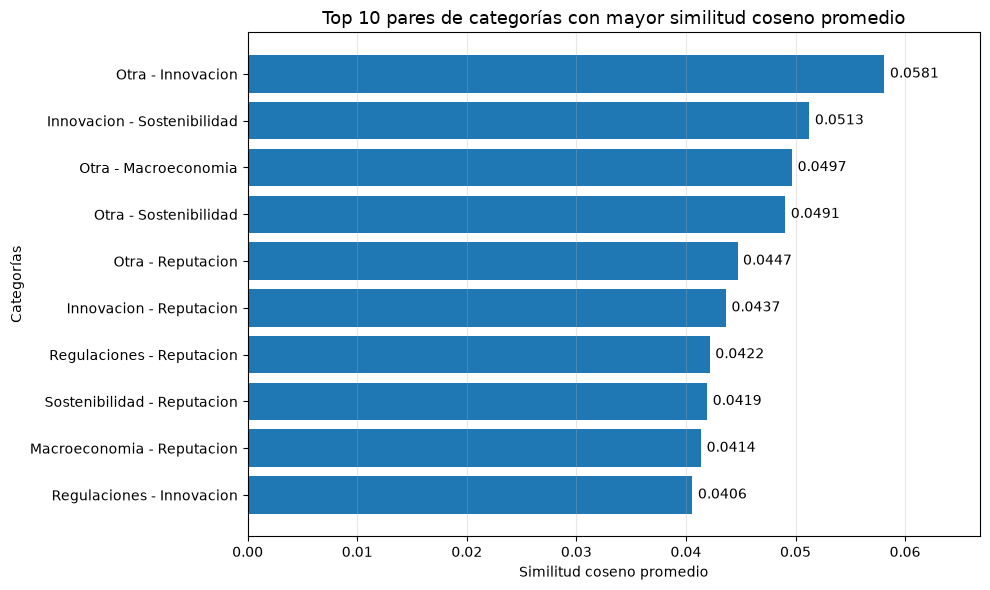

In [41]:

# Gráfica de categorías con mayor similitud promedio


# Trabajar con una copia para no modificar el DataFrame original
top10_plot = top10_categorias_similares.copy()

# Crear una etiqueta con el nombre de cada par de categorías
top10_plot["Par"] = (
    top10_plot["Categoría 1"]
    + " - "
    + top10_plot["Categoría 2"]
)

# Crear la gráfica
plt.figure(figsize=(10, 6))

barras = plt.barh(
    top10_plot["Par"],
    top10_plot["Similitud promedio"]
)

# Mostrar el par con mayor similitud en la parte superior
plt.gca().invert_yaxis()

# Agregar el valor de similitud al final de cada barra
for barra in barras:
    valor = barra.get_width()

    plt.text(
        valor + 0.0005,
        barra.get_y() + barra.get_height() / 2,
        f"{valor:.4f}",
        va="center"
    )

# Títulos y etiquetas
plt.title(
    "Top 10 pares de categorías con mayor similitud coseno promedio",
    fontsize=13
)

plt.xlabel("Similitud coseno promedio")
plt.ylabel("Categorías")

# Agregar una cuadrícula vertical para facilitar la comparación
plt.grid(axis="x", alpha=0.3)

# Dar espacio adicional para mostrar los valores
plt.xlim(
    0,
    top10_plot["Similitud promedio"].max() * 1.15
)

plt.tight_layout()
plt.show()

### Interpretación de la similitud entre categorías

Los resultados muestran que el par de categorías con mayor similitud coseno promedio es **Otra - Innovación**, con un valor de **0.0581**, seguido de **Innovación - Sostenibilidad**, con **0.0513**. También presentan similitudes relativamente altas **Otra - Macroeconomía (0.0497)** y **Otra - Sostenibilidad (0.0491)**.

Un aspecto relevante es que la categoría **Otra** aparece en varios de los pares con mayor similitud. Esto puede deberse a que esta categoría agrupa noticias que no pertenecen claramente a una temática específica, por lo que puede compartir vocabulario con categorías como Innovación, Macroeconomía, Sostenibilidad y Reputación.

Por otro lado, la similitud entre **Innovación y Sostenibilidad** puede estar relacionada con la presencia de temas comunes, como nuevos proyectos, soluciones empresariales, transformación, desarrollo e iniciativas tecnológicas o sostenibles.

Estos resultados no representan directamente errores de clasificación, ya que en este laboratorio no se entrenó un modelo clasificador. Sin embargo, permiten identificar qué categorías presentan mayor solapamiento en sus representaciones TF-IDF y, por lo tanto, cuáles podrían ser más difíciles de distinguir utilizando únicamente características léxicas.

----
-----

## LABORATORIO 3 - CLASIFICACIÓN DE TEXTO CON NAIVE BAYES

### 1. Conjuntos de entrenamiento, validación y prueba

En esta sección se divide el corpus en tres conjuntos:

- **Entrenamiento (70%)**: utilizado para que el modelo aprenda los patrones del corpus.
- **Validación (15%)**: utilizado durante el desarrollo para comparar configuraciones y tomar decisiones sobre el modelo.
- **Prueba (15%)**: utilizado únicamente al final para medir el desempeño del modelo sobre datos que no fueron utilizados durante el desarrollo.

In [42]:
# Importaciones del Laboratorio 3


from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)

import seaborn as sns

In [43]:
# Preparar variables de entrada y etiquetas


X = df["texto_normalizado"]
y = df["Type"]

print("Total de documentos:", len(X))
print("Total de categorías:", y.nunique())

Total de documentos: 1217
Total de categorías: 7


In [44]:

# Primera división:
# 70% entrenamiento y 30% temporal


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

print("Documentos de entrenamiento:", len(X_train))
print("Documentos temporales:", len(X_temp))

Documentos de entrenamiento: 851
Documentos temporales: 366


In [45]:

# Segunda división:
# 15% validación y 15% prueba


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Documentos de entrenamiento:", len(X_train))
print("Documentos de validación:", len(X_val))
print("Documentos de prueba:", len(X_test))

Documentos de entrenamiento: 851
Documentos de validación: 183
Documentos de prueba: 183


In [46]:

# Verificar proporciones


total = len(df)

print(f"Entrenamiento: {len(X_train)} documentos ({len(X_train)/total:.2%})")
print(f"Validación:    {len(X_val)} documentos ({len(X_val)/total:.2%})")
print(f"Prueba:        {len(X_test)} documentos ({len(X_test)/total:.2%})")

Entrenamiento: 851 documentos (69.93%)
Validación:    183 documentos (15.04%)
Prueba:        183 documentos (15.04%)


In [47]:

# Distribución de categorías en cada conjunto


distribucion = pd.DataFrame({
    "Entrenamiento": y_train.value_counts(),
    "Validación": y_val.value_counts(),
    "Prueba": y_test.value_counts()
}).fillna(0).astype(int)

distribucion

,Entrenamiento,Validación,Prueba
Type,,,
Macroeconomia,238,51,51
Alianzas,173,37,37
Innovacion,136,30,29
Regulaciones,99,21,22
Sostenibilidad,96,20,21
Otra,91,20,19
Reputacion,18,4,4


In [48]:
# Distribución porcentual por conjunto

distribucion_pct = pd.DataFrame({
    "Entrenamiento (%)": y_train.value_counts(normalize=True) * 100,
    "Validación (%)": y_val.value_counts(normalize=True) * 100,
    "Prueba (%)": y_test.value_counts(normalize=True) * 100
}).round(2)

distribucion_pct

,Entrenamiento (%),Validación (%),Prueba (%)
Type,,,
Macroeconomia,27.97,27.87,27.87
Alianzas,20.33,20.22,20.22
Innovacion,15.98,16.39,15.85
Regulaciones,11.63,11.48,12.02
Sostenibilidad,11.28,10.93,11.48
Otra,10.69,10.93,10.38
Reputacion,2.12,2.19,2.19


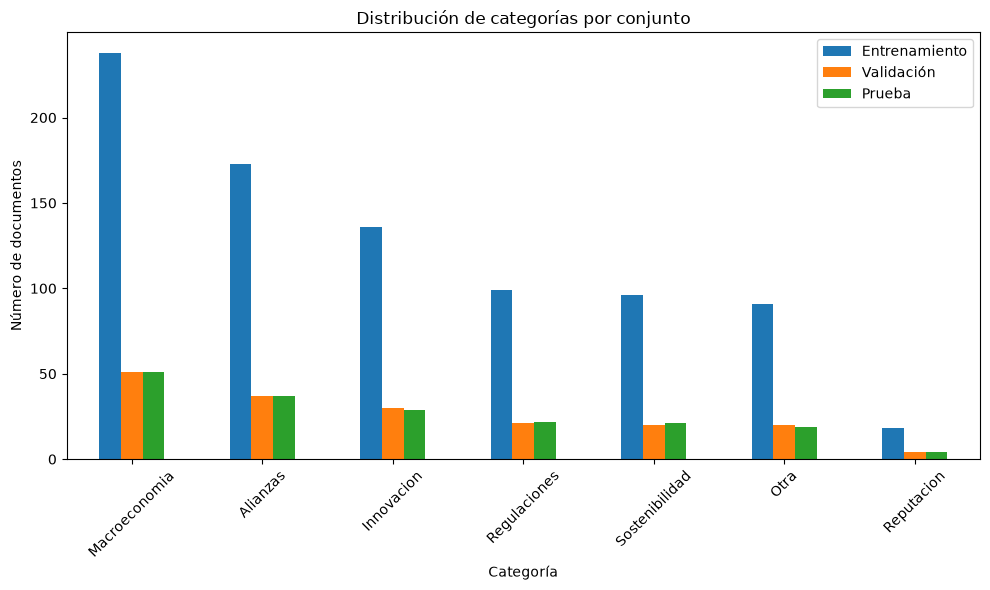

In [49]:

# Gráfica de distribución de categorías


distribucion.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribución de categorías por conjunto")
plt.xlabel("Categoría")
plt.ylabel("Número de documentos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Análisis de la división del corpus

El corpus de **1,217 noticias** se dividió en **851 documentos de entrenamiento (69.93%)**, **183 de validación (15.04%)** y **183 de prueba (15.04%)**. Las pequeñas diferencias respecto a una división exacta de 70%-15%-15% se deben al redondeo producido por el número total de documentos.

La estratificación permitió mantener una distribución de categorías muy similar en los tres conjuntos. 

El conjunto de entrenamiento será utilizado para que el modelo aprenda las probabilidades asociadas a cada categoría y a las palabras del corpus. El conjunto de validación permitirá comparar modelos y configuraciones durante el desarrollo. Finalmente, el conjunto de prueba se utilizará únicamente después de seleccionar el modelo final, con el objetivo de evaluar su capacidad de generalización sobre datos que no fueron utilizados para tomar decisiones.



## 2. Construcción del clasificador Naive Bayes

En esta sección se entrenan dos clasificadores **Multinomial Naive Bayes** utilizando diferentes representaciones del texto:

- **Bag of Words (BoW):** representa cada documento mediante la frecuencia de aparición de las palabras.
- **TF-IDF:** asigna pesos a los términos considerando tanto su frecuencia dentro del documento como su frecuencia en el corpus.

Para evitar fuga de información, los vectorizadores se ajustan (`fit`) exclusivamente con el conjunto de entrenamiento. Los conjuntos de validación y prueba se transforman posteriormente utilizando el vocabulario aprendido durante el entrenamiento.

In [50]:

# 2.1 Naive Bayes utilizando Bag of Words


# Crear el vectorizador
bow_vectorizer = CountVectorizer()

# IMPORTANTE:
# El vocabulario se aprende únicamente con entrenamiento
X_train_bow = bow_vectorizer.fit_transform(X_train)

# Validación y prueba utilizan el mismo vocabulario
X_val_bow = bow_vectorizer.transform(X_val)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW")
print("Forma entrenamiento:", X_train_bow.shape)
print("Forma validación:", X_val_bow.shape)
print("Forma prueba:", X_test_bow.shape)
print("Tamaño del vocabulario:", len(bow_vectorizer.get_feature_names_out()))

BoW
Forma entrenamiento: (851, 18239)
Forma validación: (183, 18239)
Forma prueba: (183, 18239)
Tamaño del vocabulario: 18239


In [113]:
# Entrenar Multinomial Naive Bayes con BoW


# Iniciar medición del tiempo de entrenamiento
inicio_nb_bow = time.perf_counter()

# Crear y entrenar el modelo
modelo_bow = MultinomialNB()

modelo_bow.fit(
    X_train_bow,
    y_train
)

# Finalizar medición
fin_nb_bow = time.perf_counter()

# Calcular y guardar tiempo de entrenamiento
tiempo_entrenamiento_nb_bow = (
    fin_nb_bow - inicio_nb_bow
)

print("Modelo Naive Bayes + BoW entrenado correctamente.")
print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento_nb_bow:.4f} segundos"
)

Modelo Naive Bayes + BoW entrenado correctamente.
Tiempo de entrenamiento: 0.0159 segundos


In [52]:

# 2.2 Naive Bayes utilizando TF-IDF


# Crear el vectorizador TF-IDF
tfidf_vectorizer_nb = TfidfVectorizer()

# Aprender el vocabulario e IDF SOLO con entrenamiento
X_train_tfidf = tfidf_vectorizer_nb.fit_transform(X_train)

# Transformar validación y prueba con el mismo vectorizador
X_val_tfidf = tfidf_vectorizer_nb.transform(X_val)
X_test_tfidf = tfidf_vectorizer_nb.transform(X_test)

print("TF-IDF")
print("Forma entrenamiento:", X_train_tfidf.shape)
print("Forma validación:", X_val_tfidf.shape)
print("Forma prueba:", X_test_tfidf.shape)
print(
    "Tamaño del vocabulario:",
    len(tfidf_vectorizer_nb.get_feature_names_out())
)

TF-IDF
Forma entrenamiento: (851, 18239)
Forma validación: (183, 18239)
Forma prueba: (183, 18239)
Tamaño del vocabulario: 18239


In [114]:
# Entrenar Multinomial Naive Bayes con TF-IDF


# Iniciar medición del tiempo de entrenamiento
inicio_nb_tfidf = time.perf_counter()

# Crear y entrenar el modelo
modelo_tfidf = MultinomialNB()

modelo_tfidf.fit(
    X_train_tfidf,
    y_train
)

# Finalizar medición
fin_nb_tfidf = time.perf_counter()

# Calcular y guardar tiempo de entrenamiento
tiempo_entrenamiento_nb_tfidf = (
    fin_nb_tfidf - inicio_nb_tfidf
)

print("Modelo Naive Bayes + TF-IDF entrenado correctamente.")
print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento_nb_tfidf:.4f} segundos"
)

Modelo Naive Bayes + TF-IDF entrenado correctamente.
Tiempo de entrenamiento: 0.0163 segundos


In [54]:

# Resumen de los modelos entrenados


resumen_modelos = pd.DataFrame({
    "Modelo": [
        "Naive Bayes + BoW",
        "Naive Bayes + TF-IDF"
    ],
    "Documentos entrenamiento": [
        X_train_bow.shape[0],
        X_train_tfidf.shape[0]
    ],
    "Tamaño vocabulario": [
        X_train_bow.shape[1],
        X_train_tfidf.shape[1]
    ]
})

resumen_modelos

,Modelo,Documentos entrenamiento,Tamaño vocabulario
0,Naive Bayes + BoW,851,18239
1,Naive Bayes + TF-IDF,851,18239


### Interpretación probabilística de Naive Bayes

Multinomial Naive Bayes es un clasificador probabilístico basado en el teorema de Bayes. Para clasificar una noticia nueva, el modelo estima qué categoría es más probable considerando las palabras presentes en el documento.

**P(c)** representa la probabilidad previa de una categoría. En este corpus corresponde a la proporción de documentos de entrenamiento pertenecientes a cada categoría. 

**P(wᵢ|c)** representa la probabilidad de observar una palabra determinada dada una categoría. Por ejemplo, palabras relacionadas con inflación, precios o tasas podrían presentar una probabilidad mayor dentro de Macroeconomía, mientras que términos relacionados con tecnología o digitalización podrían tener mayor probabilidad dentro de Innovación.

Para clasificar un documento nuevo, Naive Bayes combina la probabilidad previa de cada categoría con las probabilidades de las palabras observadas en el documento. El modelo calcula un puntaje para cada categoría y selecciona aquella que obtiene el valor más alto.


In [55]:

# 3. Entrenamiento y evaluación

# Predicciones del modelo BoW
y_train_pred_bow = modelo_bow.predict(X_train_bow)
y_val_pred_bow = modelo_bow.predict(X_val_bow)

# Predicciones del modelo TF-IDF
y_train_pred_tfidf = modelo_tfidf.predict(X_train_tfidf)
y_val_pred_tfidf = modelo_tfidf.predict(X_val_tfidf)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


In [56]:

# Función para calcular métricas


def calcular_metricas(y_real, y_pred):
    return {
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision macro": precision_score(
            y_real, y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall macro": recall_score(
            y_real, y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 macro": f1_score(
            y_real, y_pred,
            average="macro",
            zero_division=0
        ),
        "Precision ponderado": precision_score(
            y_real, y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall ponderado": recall_score(
            y_real, y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1 ponderado": f1_score(
            y_real, y_pred,
            average="weighted",
            zero_division=0
        )
    }

In [57]:

# Comparar entrenamiento y validación


resultados_evaluacion = pd.DataFrame([
    {
        "Modelo": "BoW",
        "Conjunto": "Entrenamiento",
        **calcular_metricas(y_train, y_train_pred_bow)
    },
    {
        "Modelo": "BoW",
        "Conjunto": "Validación",
        **calcular_metricas(y_val, y_val_pred_bow)
    },
    {
        "Modelo": "TF-IDF",
        "Conjunto": "Entrenamiento",
        **calcular_metricas(y_train, y_train_pred_tfidf)
    },
    {
        "Modelo": "TF-IDF",
        "Conjunto": "Validación",
        **calcular_metricas(y_val, y_val_pred_tfidf)
    }
])

# Redondear para facilitar la lectura
columnas_metricas = resultados_evaluacion.columns[2:]

resultados_evaluacion[columnas_metricas] = (
    resultados_evaluacion[columnas_metricas].round(4)
)

resultados_evaluacion

,Modelo,Conjunto,Accuracy,Precision macro,Recall macro,F1 macro,Precision ponderado,Recall ponderado,F1 ponderado
0,BoW,Entrenamiento,0.9471,0.9551,0.9365,0.9443,0.9498,0.9471,0.9473
1,BoW,Validación,0.8142,0.8386,0.7302,0.7389,0.8279,0.8142,0.8042
2,TF-IDF,Entrenamiento,0.7203,0.7529,0.5385,0.5363,0.8039,0.7203,0.6662
3,TF-IDF,Validación,0.5792,0.4419,0.3974,0.3751,0.5337,0.5792,0.5023


In [58]:

# Classification Report - BoW - Validación


print("CLASSIFICATION REPORT - BoW - VALIDACIÓN\n")

print(
    classification_report(
        y_val,
        y_val_pred_bow,
        digits=4,
        zero_division=0
    )
)

CLASSIFICATION REPORT - BoW - VALIDACIÓN

                precision    recall  f1-score   support

      Alianzas     0.8333    0.6757    0.7463        37
    Innovacion     0.7692    1.0000    0.8696        30
 Macroeconomia     0.8868    0.9216    0.9038        51
          Otra     0.9167    0.5500    0.6875        20
  Regulaciones     0.7500    0.7143    0.7317        21
    Reputacion     1.0000    0.2500    0.4000         4
Sostenibilidad     0.7143    1.0000    0.8333        20

      accuracy                         0.8142       183
     macro avg     0.8386    0.7302    0.7389       183
  weighted avg     0.8279    0.8142    0.8042       183



In [59]:

# Classification Report - TF-IDF - Validación


print("CLASSIFICATION REPORT - TF-IDF - VALIDACIÓN\n")

print(
    classification_report(
        y_val,
        y_val_pred_tfidf,
        digits=4,
        zero_division=0
    )
)

CLASSIFICATION REPORT - TF-IDF - VALIDACIÓN

                precision    recall  f1-score   support

      Alianzas     0.8276    0.6486    0.7273        37
    Innovacion     0.8333    0.8333    0.8333        30
 Macroeconomia     0.4322    1.0000    0.6036        51
          Otra     0.0000    0.0000    0.0000        20
  Regulaciones     0.0000    0.0000    0.0000        21
    Reputacion     0.0000    0.0000    0.0000         4
Sostenibilidad     1.0000    0.3000    0.4615        20

      accuracy                         0.5792       183
     macro avg     0.4419    0.3974    0.3751       183
  weighted avg     0.5337    0.5792    0.5023       183



In [60]:
# Orden de categorías para las matrices de confusión

categorias_modelo = sorted(y.unique())

categorias_modelo

['Alianzas',
 'Innovacion',
 'Macroeconomia',
 'Otra',
 'Regulaciones',
 'Reputacion',
 'Sostenibilidad']

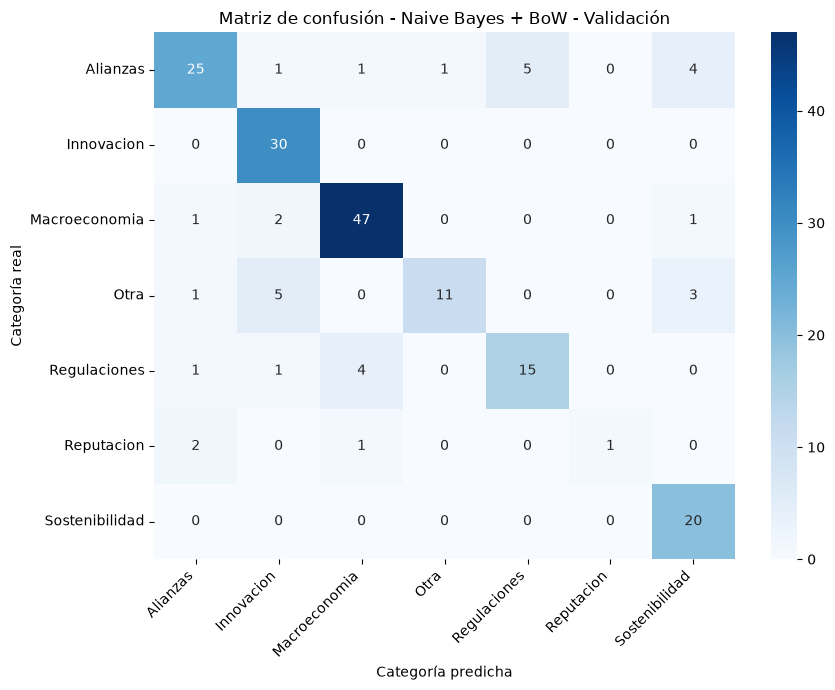

In [61]:

# Matriz de confusión - BoW - Validación

cm_bow = confusion_matrix(
    y_val,
    y_val_pred_bow,
    labels=categorias_modelo
)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm_bow,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=categorias_modelo,
    yticklabels=categorias_modelo
)

plt.title("Matriz de confusión - Naive Bayes + BoW - Validación")
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

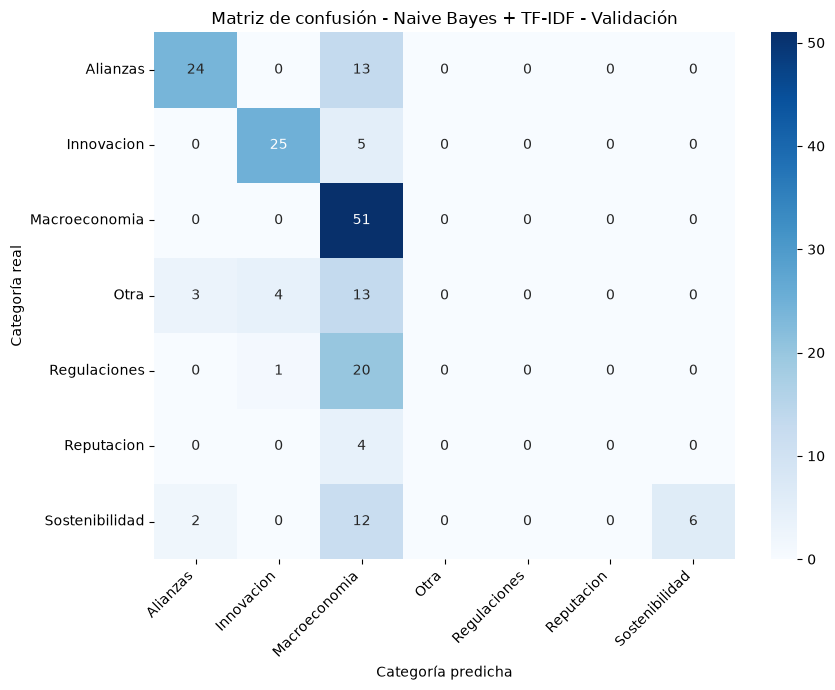

In [62]:

# Matriz de confusión - TF-IDF - Validación


cm_tfidf = confusion_matrix(
    y_val,
    y_val_pred_tfidf,
    labels=categorias_modelo
)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm_tfidf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=categorias_modelo,
    yticklabels=categorias_modelo
)

plt.title("Matriz de confusión - Naive Bayes + TF-IDF - Validación")
plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Análisis del desempeño de BoW y TF-IDF

Los resultados muestran una diferencia importante entre las dos representaciones utilizadas con Multinomial Naive Bayes.

El modelo basado en **Bag of Words (BoW)** obtuvo un accuracy de **94.71% en entrenamiento** y **81.42% en validación**. Su F1 macro disminuyó de **0.9443 a 0.7389**, mientras que el F1 ponderado pasó de **0.9473 a 0.8042**. Esto indica que el modelo aprende con bastante precisión los documentos de entrenamiento y mantiene un desempeño razonablemente alto sobre datos no vistos.

Existe una diferencia de aproximadamente **13 puntos porcentuales de accuracy** entre entrenamiento y validación, por lo que se observa cierto grado de sobreajuste. Sin embargo, el modelo todavía logra generalizar razonablemente bien, ya que supera el 81% de accuracy en validación.

El modelo basado en **TF-IDF** presentó un desempeño considerablemente menor. Su accuracy fue de **72.03% en entrenamiento** y solamente **57.92% en validación**. Además, el F1 macro en validación fue de **0.3751**, muy inferior al **0.7389** obtenido por BoW.

En este experimento, por lo tanto, **Bag of Words es claramente la representación más adecuada para Multinomial Naive Bayes**. Una posible explicación es que este clasificador está especialmente adaptado a datos multinomiales basados en frecuencias. BoW conserva directamente los conteos de las palabras, mientras que TF-IDF modifica esos valores mediante ponderaciones que reducen la influencia de términos frecuentes. En este corpus, los conteos parecen proporcionar señales más útiles para distinguir las categorías.

### Desempeño por categoría

La matriz de confusión muestra que el modelo BoW presenta un comportamiento más equilibrado entre las categorías. **Innovación y Sostenibilidad** fueron clasificadas correctamente en todos los documentos del conjunto de validación, mientras que Macroeconomía también obtuvo un recall elevado de **0.9216**.

Las mayores dificultades aparecen en **Otras** y especialmente en **Reputación**. Reputación obtuvo un recall de solamente **0.25**, aunque este resultado debe interpretarse con precaución porque el conjunto de validación contiene únicamente cuatro documentos de esta categoría.

El modelo TF-IDF presenta un comportamiento mucho más sesgado. No logró identificar correctamente ningún documento de las categorías **Otra, Regulaciones y Reputación**, y una gran cantidad de estos documentos fueron clasificados como Macroeconomía. 

In [63]:

# 4. Análisis de errores
# 4.1 Categorías con mayor confusión


# La matriz cm_bow ya contiene:
# filas    = categoría real
# columnas = categoría predicha

# Copiamos la matriz para no modificar la original
cm_bow_errores = cm_bow.copy()

# Eliminamos los aciertos de la diagonal
np.fill_diagonal(cm_bow_errores, 0)

# Buscar la posición del mayor valor fuera de la diagonal
i, j = np.unravel_index(
    np.argmax(cm_bow_errores),
    cm_bow_errores.shape
)

categoria_real_mayor_confusion = categorias_modelo[i]
categoria_predicha_mayor_confusion = categorias_modelo[j]

confusiones_mayor = cm_bow_errores[i, j]

print("Mayor confusión:")
print(
    f"{categoria_real_mayor_confusion} -> "
    f"{categoria_predicha_mayor_confusion}: "
    f"{confusiones_mayor} documentos"
)

Mayor confusión:
Alianzas -> Regulaciones: 5 documentos


In [64]:
# Obtener todas las confusiones fuera de la diagonal
confusiones = []

for i in range(len(categorias_modelo)):
    for j in range(len(categorias_modelo)):
        if i != j and cm_bow[i, j] > 0:
            confusiones.append({
                "Categoría real": categorias_modelo[i],
                "Categoría predicha": categorias_modelo[j],
                "Errores": cm_bow[i, j]
            })

df_confusiones = (
    pd.DataFrame(confusiones)
    .sort_values("Errores", ascending=False)
    .reset_index(drop=True)
)

df_confusiones.head(10)

,Categoría real,Categoría predicha,Errores
0,Alianzas,Regulaciones,5
1,Otra,Innovacion,5
2,Alianzas,Sostenibilidad,4
3,Regulaciones,Macroeconomia,4
4,Otra,Sostenibilidad,3
5,Macroeconomia,Innovacion,2
6,Reputacion,Alianzas,2
7,Alianzas,Innovacion,1
8,Alianzas,Macroeconomia,1
9,Alianzas,Otra,1


In [65]:

# Documentos del conjunto de validación y sus predicciones


df_val_resultados = pd.DataFrame({
    "Texto": X_val,
    "Categoria_real": y_val,
    "Categoria_predicha": y_val_pred_bow
})

# Reiniciar índice para facilitar la revisión
df_val_resultados = df_val_resultados.reset_index()
df_val_resultados = df_val_resultados.rename(
    columns={"index": "Indice"}
)

df_val_resultados.head()

,Indice,Texto,Categoria_real,Categoria_predicha
0,310,aunque año completo actividad económico visto ...,Regulaciones,Macroeconomia
1,237,prolongación vida laboral mejorar sostenibilid...,Sostenibilidad,Sostenibilidad
2,8,factor humano normalmente identificado factor ...,Innovacion,Innovacion
3,357,bbva inaugurado primero dos centro tecnológico...,Innovacion,Innovacion
4,338,paquete fiscal presentado secretacer haciendo ...,Macroeconomia,Macroeconomia


In [66]:

# Errores entre las dos categorías más confundidas


errores_categoria_1 = df_val_resultados[
    (df_val_resultados["Categoria_real"] == categoria_real_mayor_confusion) &
    (df_val_resultados["Categoria_predicha"] == categoria_predicha_mayor_confusion)
]

errores_categoria_2 = df_val_resultados[
    (df_val_resultados["Categoria_real"] == categoria_predicha_mayor_confusion) &
    (df_val_resultados["Categoria_predicha"] == categoria_real_mayor_confusion)
]

print(
    f"Errores {categoria_real_mayor_confusion} -> "
    f"{categoria_predicha_mayor_confusion}: {len(errores_categoria_1)}"
)

print(
    f"Errores {categoria_predicha_mayor_confusion} -> "
    f"{categoria_real_mayor_confusion}: {len(errores_categoria_2)}"
)

Errores Alianzas -> Regulaciones: 5
Errores Regulaciones -> Alianzas: 1


In [67]:
# Mostrar hasta 5 documentos mal clasificados
# de cada dirección de la confusión

print(
    f"\nErrores: {categoria_real_mayor_confusion} "
    f"-> {categoria_predicha_mayor_confusion}"
)

display(
    errores_categoria_1[
        ["Indice", "Categoria_real", "Categoria_predicha", "Texto"]
    ].head(5)
)

print(
    f"\nErrores: {categoria_predicha_mayor_confusion} "
    f"-> {categoria_real_mayor_confusion}"
)

display(
    errores_categoria_2[
        ["Indice", "Categoria_real", "Categoria_predicha", "Texto"]
    ].head(5)
)


Errores: Alianzas -> Regulaciones


,Indice,Categoria_real,Categoria_predicha,Texto
106,694,Alianzas,Regulaciones,uber taxi cumplir mes primero aniversario colo...
120,452,Alianzas,Regulaciones,menos semana segundo vuelta presidencial kwai ...
121,806,Alianzas,Regulaciones,taxexpress uber anunciar lanzamiento uber taxi...
125,72,Alianzas,Regulaciones,hacer exactamente cuatro año escribir espaceír...
175,613,Alianzas,Regulaciones,alguno insultar hoy persona deber convivir mañ...



Errores: Regulaciones -> Alianzas


,Indice,Categoria_real,Categoria_predicha,Texto
149,1195,Regulaciones,Alianzas,año pasado fabricación producto farmacéutico s...


In [68]:

# Palabras con mayor P(w_i | c)

vocab_bow = bow_vectorizer.get_feature_names_out()

probabilidades_palabras = np.exp(
    modelo_bow.feature_log_prob_
)

print("Forma de la matriz de probabilidades:",
      probabilidades_palabras.shape)

Forma de la matriz de probabilidades: (7, 18239)


In [69]:
def top_palabras_por_categoria(modelo, vectorizer, categorias, categoria, n=15):
    """
    Devuelve las palabras con mayor P(w_i | c)
    para una categoría específica.
    """

    indice_categoria = list(modelo.classes_).index(categoria)

    probabilidades = np.exp(
        modelo.feature_log_prob_[indice_categoria]
    )

    vocabulario = vectorizer.get_feature_names_out()

    indices_top = probabilidades.argsort()[::-1][:n]

    return pd.DataFrame({
        "Palabra": vocabulario[indices_top],
        "P(w|c)": probabilidades[indices_top]
    })

In [70]:

# Top palabras por probabilidad condicional


categorias_analisis = [
    "Macroeconomia",
    "Innovacion",
    "Sostenibilidad"
]

for categoria in categorias_analisis:

    print("\n" + "=" * 60)
    print(f"Categoría: {categoria}")
    print("=" * 60)

    display(
        top_palabras_por_categoria(
            modelo_bow,
            bow_vectorizer,
            categorias_modelo,
            categoria,
            n=15
        )
    )


Categoría: Macroeconomia


,Palabra,P(w|c)
0,inflación,0.010726
1,año,0.008000
2,precio,0.007731
3,poder,0.005965
4,bbva,0.004690
5,país,0.004398
6,él,0.004363
7,mes,0.004304
8,mayor,0.004258
9,tasa,0.004164



Categoría: Innovacion


,Palabra,P(w|c)
0,bbva,0.013295
1,poder,0.006596
2,él,0.004999
3,cliente,0.004842
4,banco,0.004565
5,nuevo,0.004339
6,digital,0.004235
7,permitir,0.004061
8,empresa,0.003888
9,financiero,0.003714



Categoría: Sostenibilidad


,Palabra,P(w|c)
0,bbva,0.006179
1,él,0.005296
2,poder,0.005180
3,sostenible,0.004747
4,energía,0.003481
5,sostenibilidad,0.003131
6,objetivo,0.003031
7,agua,0.002981
8,año,0.002848
9,cambio,0.002565


In [71]:
# Preparar variables de entrada y etiquetas


X = df["texto_normalizado"]
y = df["Type"]

print("Total de documentos:", len(X))
print("Total de categorías:", y.nunique())

Total de documentos: 1217
Total de categorías: 7


### Palabras con mayor probabilidad condicional por categoría

Las palabras con mayor **P(w|c)** permiten observar qué términos considera Naive Bayes más probables dentro de cada categoría.

En **Macroeconomía** aparecen términos como *inflación*, *precio*, *tasa*, *crecimiento*, *aumento* y *económico*. Estas palabras tienen una relación clara con noticias sobre indicadores económicos y comportamiento de la economía.

En **Innovación** aparecen términos como *cliente*, *nuevo*, *digital*, *dato*, *servicio* e *innovación*, relacionados con transformación digital, nuevos productos y servicios.

En **Sostenibilidad** destacan *sostenible*, *energía*, *sostenibilidad*, *agua*, *eléctrico* y *climático*, que representan claramente temas ambientales y de desarrollo sostenible.

Por lo tanto, una parte importante de las palabras con mayor probabilidad condicional sí tiene sentido como vocabulario representativo de las categorías. Sin embargo, también aparecen palabras generales como *poder*, *año*, *hacer*, *él* o incluso *BBVA*, que están presentes en diferentes categorías y tienen menor capacidad para distinguirlas.

### Relación con el supuesto de independencia condicional


Los errores encontrados entre Alianzas y Regulaciones permiten observar esta limitación. Una noticia puede contener términos relacionados con empresas, servicios, acuerdos y regulaciones al mismo tiempo. Naive Bayes evalúa estas palabras como señales individuales y combina sus probabilidades, pero no considera suficientemente relaciones como qué empresa realiza una acción, si una regulación es el tema principal de la noticia o si solamente se menciona dentro de una alianza empresarial.

Por ejemplo, la aparición de vocabulario asociado con Uber, taxis, productos o empresas puede aportar evidencia a varias categorías. Al tratar estas señales como independientes, el modelo puede acumular suficiente probabilidad para seleccionar una categoría incorrecta.

A pesar de este supuesto simplificado, el modelo obtuvo buenos resultados generales porque muchas categorías contienen palabras suficientemente características. Cuando términos como *inflación*, *tasa* y *precio* aparecen conjuntamente, por ejemplo, proporcionan varias señales que favorecen Macroeconomía, aunque el modelo no represente explícitamente la relación entre ellas.

In [72]:

# 5. Efecto de la representación de texto
# 5.1 BoW con las 1000 palabras más frecuentes


bow_1000 = CountVectorizer(max_features=1000)

# Ajustar únicamente con entrenamiento
X_train_bow_1000 = bow_1000.fit_transform(X_train)

# Transformar validación con el vocabulario aprendido
X_val_bow_1000 = bow_1000.transform(X_val)

# Entrenar Naive Bayes
modelo_bow_1000 = MultinomialNB()
modelo_bow_1000.fit(X_train_bow_1000, y_train)

# Predicciones
y_train_pred_bow_1000 = modelo_bow_1000.predict(X_train_bow_1000)
y_val_pred_bow_1000 = modelo_bow_1000.predict(X_val_bow_1000)

print("Tamaño del vocabulario:", X_train_bow_1000.shape[1])
print(
    "Accuracy validación:",
    round(accuracy_score(y_val, y_val_pred_bow_1000), 4)
)
print(
    "F1 macro validación:",
    round(
        f1_score(
            y_val,
            y_val_pred_bow_1000,
            average="macro",
            zero_division=0
        ),
        4
    )
)

Tamaño del vocabulario: 1000
Accuracy validación: 0.8197
F1 macro validación: 0.8216


In [73]:

# 5.2 BoW con las 5000 palabras más frecuentes


bow_5000 = CountVectorizer(max_features=5000)

X_train_bow_5000 = bow_5000.fit_transform(X_train)
X_val_bow_5000 = bow_5000.transform(X_val)

modelo_bow_5000 = MultinomialNB()
modelo_bow_5000.fit(X_train_bow_5000, y_train)

y_train_pred_bow_5000 = modelo_bow_5000.predict(X_train_bow_5000)
y_val_pred_bow_5000 = modelo_bow_5000.predict(X_val_bow_5000)

print("Tamaño del vocabulario:", X_train_bow_5000.shape[1])
print(
    "Accuracy validación:",
    round(accuracy_score(y_val, y_val_pred_bow_5000), 4)
)
print(
    "F1 macro validación:",
    round(
        f1_score(
            y_val,
            y_val_pred_bow_5000,
            average="macro",
            zero_division=0
        ),
        4
    )
)

Tamaño del vocabulario: 5000
Accuracy validación: 0.8197
F1 macro validación: 0.8219


In [74]:

# 5.3 BoW con unigramas + bigramas

import time

inicio_vectorizacion = time.perf_counter()

bow_bigramas = CountVectorizer(
    ngram_range=(1, 2)
)

X_train_bow_bigramas = bow_bigramas.fit_transform(X_train)
X_val_bow_bigramas = bow_bigramas.transform(X_val)

fin_vectorizacion = time.perf_counter()

# Medir tiempo de entrenamiento
inicio_entrenamiento = time.perf_counter()

modelo_bow_bigramas = MultinomialNB()
modelo_bow_bigramas.fit(
    X_train_bow_bigramas,
    y_train
)

fin_entrenamiento = time.perf_counter()

# Predicciones
y_train_pred_bow_bigramas = modelo_bow_bigramas.predict(
    X_train_bow_bigramas
)

y_val_pred_bow_bigramas = modelo_bow_bigramas.predict(
    X_val_bow_bigramas
)

tiempo_vectorizacion_bigramas = (
    fin_vectorizacion - inicio_vectorizacion
)

tiempo_entrenamiento_bigramas = (
    fin_entrenamiento - inicio_entrenamiento
)

print(
    "Tamaño del vocabulario:",
    X_train_bow_bigramas.shape[1]
)

print(
    "Tiempo de vectorización:",
    round(tiempo_vectorizacion_bigramas, 4),
    "segundos"
)

print(
    "Tiempo de entrenamiento:",
    round(tiempo_entrenamiento_bigramas, 4),
    "segundos"
)

print(
    "Accuracy validación:",
    round(
        accuracy_score(
            y_val,
            y_val_pred_bow_bigramas
        ),
        4
    )
)

print(
    "F1 macro validación:",
    round(
        f1_score(
            y_val,
            y_val_pred_bow_bigramas,
            average="macro",
            zero_division=0
        ),
        4
    )
)

Tamaño del vocabulario: 184605
Tiempo de vectorización: 0.6494 segundos
Tiempo de entrenamiento: 0.0268 segundos
Accuracy validación: 0.7432
F1 macro validación: 0.6507


In [75]:

# Tabla comparativa de representaciones

comparacion_modelos = pd.DataFrame([
    {
        "Representación": "BoW completo",
        "Vocabulario": X_train_bow.shape[1],
        "Accuracy": accuracy_score(
            y_val,
            y_val_pred_bow
        ),
        "F1 macro": f1_score(
            y_val,
            y_val_pred_bow,
            average="macro",
            zero_division=0
        )
    },
    {
        "Representación": "TF-IDF",
        "Vocabulario": X_train_tfidf.shape[1],
        "Accuracy": accuracy_score(
            y_val,
            y_val_pred_tfidf
        ),
        "F1 macro": f1_score(
            y_val,
            y_val_pred_tfidf,
            average="macro",
            zero_division=0
        )
    },
    {
        "Representación": "BoW - 1000 palabras",
        "Vocabulario": X_train_bow_1000.shape[1],
        "Accuracy": accuracy_score(
            y_val,
            y_val_pred_bow_1000
        ),
        "F1 macro": f1_score(
            y_val,
            y_val_pred_bow_1000,
            average="macro",
            zero_division=0
        )
    },
    {
        "Representación": "BoW - 5000 palabras",
        "Vocabulario": X_train_bow_5000.shape[1],
        "Accuracy": accuracy_score(
            y_val,
            y_val_pred_bow_5000
        ),
        "F1 macro": f1_score(
            y_val,
            y_val_pred_bow_5000,
            average="macro",
            zero_division=0
        )
    },
    {
        "Representación": "BoW - unigramas + bigramas",
        "Vocabulario": X_train_bow_bigramas.shape[1],
        "Accuracy": accuracy_score(
            y_val,
            y_val_pred_bow_bigramas
        ),
        "F1 macro": f1_score(
            y_val,
            y_val_pred_bow_bigramas,
            average="macro",
            zero_division=0
        )
    }
])

comparacion_modelos[
    ["Accuracy", "F1 macro"]
] = comparacion_modelos[
    ["Accuracy", "F1 macro"]
].round(4)

comparacion_modelos = comparacion_modelos.sort_values(
    "F1 macro",
    ascending=False
).reset_index(drop=True)

comparacion_modelos

,Representación,Vocabulario,Accuracy,F1 macro
0,BoW - 5000 palabras,5000,0.8197,0.8219
1,BoW - 1000 palabras,1000,0.8197,0.8216
2,BoW completo,18239,0.8142,0.7389
3,BoW - unigramas + bigramas,184605,0.7432,0.6507
4,TF-IDF,18239,0.5792,0.3751


In [76]:
# Comparación del tamaño del vocabulario

print(
    "BoW solo unigramas:",
    X_train_bow.shape[1],
    "características"
)

print(
    "BoW unigramas + bigramas:",
    X_train_bow_bigramas.shape[1],
    "características"
)

incremento_vocabulario = (
    (
        X_train_bow_bigramas.shape[1]
        - X_train_bow.shape[1]
    )
    / X_train_bow.shape[1]
) * 100

print(
    f"Incremento del vocabulario: "
    f"{incremento_vocabulario:.2f}%"
)

BoW solo unigramas: 18239 características
BoW unigramas + bigramas: 184605 características
Incremento del vocabulario: 912.14%


### Análisis del efecto del tamaño del vocabulario

Los resultados muestran que limitar el vocabulario de Bag of Words produjo una mejora en el desempeño del clasificador.

El modelo con el vocabulario completo de **18,239 términos** obtuvo un accuracy de **0.8142** y un F1 macro de **0.7389**. Al limitar el vocabulario a las **1,000 palabras más frecuentes**, el accuracy aumentó a **0.8197** y el F1 macro a **0.8216**. Con **5,000 palabras**, el accuracy se mantuvo en **0.8197**, mientras que el F1 macro alcanzó **0.8219**, siendo ligeramente superior.

Esto indica que utilizar todo el vocabulario no necesariamente mejora la clasificación. Los términos poco frecuentes pueden agregar características con poca información útil o introducir ruido. Al conservar las palabras más frecuentes, el modelo trabaja con un espacio de características más reducido y mantiene las señales más útiles para distinguir las categorías.

Entre las configuraciones evaluadas, **BoW con 5,000 palabras obtuvo el mejor F1 macro**, aunque su diferencia respecto al modelo de 1,000 palabras es muy pequeña.

### Efecto de agregar bigramas

Agregar bigramas junto con los unigramas no mejoró el desempeño del clasificador. El vocabulario aumentó de **18,239 a 184,605 características**, lo que representa un incremento de aproximadamente **912.14%**.

A pesar del considerable aumento en dimensionalidad, el accuracy disminuyó de **0.8142 a 0.7432** y el F1 macro pasó de **0.7389 a 0.6507**.

Los bigramas pueden capturar información contextual que los unigramas no representan, ya que consideran pares de palabras consecutivas. Sin embargo, también generan una gran cantidad de combinaciones poco frecuentes. En este corpus, ese aumento produjo un espacio de características mucho más grande y disperso sin aportar suficiente información adicional para mejorar la clasificación.

Por lo tanto, el costo de utilizar unigramas y bigramas fue considerable en términos de tamaño del vocabulario y tiempo de vectorización, mientras que el desempeño del modelo disminuyó.

In [77]:

# Implementación propia de Multinomial Naive Bayes


class NaiveBayesPropio:

    def __init__(self, alpha=1.0):
        # Parámetro para el suavizado de Laplace
        self.alpha = alpha

    def fit(self, X, y):

        # Convertir etiquetas a arreglo de NumPy
        y = np.asarray(y)

        # Obtener las categorías disponibles
        self.classes_ = np.unique(y)

        # Número de categorías y palabras
        n_clases = len(self.classes_)
        n_features = X.shape[1]

        # Aquí guardaremos log P(c)
        self.class_log_prior_ = np.zeros(n_clases)

        # Aquí guardaremos log P(w_i | c)
        self.feature_log_prob_ = np.zeros(
            (n_clases, n_features)
        )

        # Calcular probabilidades para cada categoría
        for i, categoria in enumerate(self.classes_):

            # Documentos pertenecientes a la categoría
            mascara = (y == categoria)

            X_categoria = X[mascara]

            # --------------------------------------------
            # 1. Probabilidad previa P(c)
            # --------------------------------------------

            n_documentos_categoria = X_categoria.shape[0]
            n_documentos_total = X.shape[0]

            prob_categoria = (
                n_documentos_categoria /
                n_documentos_total
            )

            self.class_log_prior_[i] = np.log(
                prob_categoria
            )

            # --------------------------------------------
            # 2. Conteos de palabras por categoría
            # --------------------------------------------

            conteos_palabras = np.asarray(
                X_categoria.sum(axis=0)
            ).ravel()

            # --------------------------------------------
            # 3. Suavizado de Laplace
            # --------------------------------------------

            conteos_suavizados = (
                conteos_palabras + self.alpha
            )

            total_palabras = conteos_palabras.sum()

            denominador = (
                total_palabras
                + self.alpha * n_features
            )

            probabilidades = (
                conteos_suavizados / denominador
            )

            # --------------------------------------------
            # 4. Guardar log P(w_i | c)
            # --------------------------------------------

            self.feature_log_prob_[i] = np.log(
                probabilidades
            )

        return self

In [78]:
    def predict(self, X):

        # Puntaje de cada documento para cada categoría
        scores = (
            X @ self.feature_log_prob_.T
            + self.class_log_prior_
        )

        # Convertir a array por seguridad
        scores = np.asarray(scores)

        # Categoría con mayor puntaje
        indices = np.argmax(scores, axis=1)

        return self.classes_[indices]

In [79]:
class NaiveBayesPropio:

    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):

        y = np.asarray(y)

        self.classes_ = np.unique(y)

        n_clases = len(self.classes_)
        n_features = X.shape[1]

        self.class_log_prior_ = np.zeros(n_clases)

        self.feature_log_prob_ = np.zeros(
            (n_clases, n_features)
        )

        for i, categoria in enumerate(self.classes_):

            mascara = (y == categoria)

            X_categoria = X[mascara]

            # P(c)
            prob_categoria = (
                X_categoria.shape[0] /
                X.shape[0]
            )

            self.class_log_prior_[i] = np.log(
                prob_categoria
            )

            # Conteos por palabra
            conteos_palabras = np.asarray(
                X_categoria.sum(axis=0)
            ).ravel()

            # Suavizado de Laplace
            conteos_suavizados = (
                conteos_palabras + self.alpha
            )

            denominador = (
                conteos_palabras.sum()
                + self.alpha * n_features
            )

            probabilidades = (
                conteos_suavizados /
                denominador
            )

            self.feature_log_prob_[i] = np.log(
                probabilidades
            )

        return self

    def predict(self, X):

        scores = (
            X @ self.feature_log_prob_.T
            + self.class_log_prior_
        )

        scores = np.asarray(scores)

        indices = np.argmax(
            scores,
            axis=1
        )

        return self.classes_[indices]

In [80]:

# Entrenar Naive Bayes propio


modelo_nb_propio = NaiveBayesPropio(alpha=1.0)

modelo_nb_propio.fit(
    X_train_bow_5000,
    y_train
)

print("Modelo Naive Bayes propio entrenado correctamente.")

Modelo Naive Bayes propio entrenado correctamente.


In [81]:
# Predicciones con nuestra implementación

y_train_pred_propio = modelo_nb_propio.predict(
    X_train_bow_5000
)

y_val_pred_propio = modelo_nb_propio.predict(
    X_val_bow_5000
)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


In [82]:

# Evaluación de la implementación propia


accuracy_propio = accuracy_score(
    y_val,
    y_val_pred_propio
)

f1_macro_propio = f1_score(
    y_val,
    y_val_pred_propio,
    average="macro",
    zero_division=0
)

print(
    "Accuracy validación:",
    round(accuracy_propio, 4)
)

print(
    "F1 macro validación:",
    round(f1_macro_propio, 4)
)

Accuracy validación: 0.8197
F1 macro validación: 0.8219


In [83]:
print(
    classification_report(
        y_val,
        y_val_pred_propio,
        digits=4,
        zero_division=0
    )
)

                precision    recall  f1-score   support

      Alianzas     0.8571    0.6486    0.7385        37
    Innovacion     0.7838    0.9667    0.8657        30
 Macroeconomia     0.9200    0.9020    0.9109        51
          Otra     0.8000    0.6000    0.6857        20
  Regulaciones     0.7273    0.7619    0.7442        21
    Reputacion     1.0000    1.0000    1.0000         4
Sostenibilidad     0.7037    0.9500    0.8085        20

      accuracy                         0.8197       183
     macro avg     0.8274    0.8327    0.8219       183
  weighted avg     0.8278    0.8197    0.8156       183



In [84]:

# Comparar implementación propia vs scikit-learn


predicciones_iguales = np.mean(
    y_val_pred_propio == y_val_pred_bow_5000
)

print(
    f"Predicciones iguales: "
    f"{predicciones_iguales:.2%}"
)

Predicciones iguales: 100.00%


In [85]:
# Agregar implementación propia a la comparación

fila_propia = pd.DataFrame([{
    "Representación": "BoW 5000 - Naive Bayes propio",
    "Vocabulario": X_train_bow_5000.shape[1],
    "Accuracy": accuracy_propio,
    "F1 macro": f1_macro_propio
}])

comparacion_modelos_final = pd.concat(
    [
        comparacion_modelos,
        fila_propia
    ],
    ignore_index=True
)

comparacion_modelos_final[
    ["Accuracy", "F1 macro"]
] = comparacion_modelos_final[
    ["Accuracy", "F1 macro"]
].round(4)

comparacion_modelos_final = (
    comparacion_modelos_final
    .sort_values(
        "F1 macro",
        ascending=False
    )
    .reset_index(drop=True)
)

comparacion_modelos_final

,Representación,Vocabulario,Accuracy,F1 macro
0,BoW - 5000 palabras,5000,0.8197,0.8219
1,BoW 5000 - Naive Bayes propio,5000,0.8197,0.8219
2,BoW - 1000 palabras,1000,0.8197,0.8216
3,BoW completo,18239,0.8142,0.7389
4,BoW - unigramas + bigramas,184605,0.7432,0.6507
5,TF-IDF,18239,0.5792,0.3751


In [86]:
# Preparar variables de entrada y etiquetas


X = df["texto_normalizado"]
y = df["Type"]

print("Total de documentos:", len(X))
print("Total de categorías:", y.nunique())

Total de documentos: 1217
Total de categorías: 7


### Comparación de la implementación propia con scikit-learn

La implementación propia de Multinomial Naive Bayes obtuvo un **accuracy de 0.8197** y un **F1 macro de 0.8219** utilizando una representación BoW limitada a 5,000 palabras.

Al comparar sus predicciones con las generadas por `MultinomialNB` de scikit-learn utilizando exactamente los mismos datos, vocabulario y parámetro de suavizado, se obtuvo una coincidencia del **100% de las predicciones**.

Este resultado indica que la implementación propia reproduce correctamente los componentes fundamentales de Multinomial Naive Bayes: el cálculo de la probabilidad previa de cada clase P(c), las probabilidades condicionales P(wᵢ|c), el suavizado de Laplace y el uso de logaritmos para combinar las probabilidades.

La implementación permitió observar de forma explícita operaciones que `MultinomialNB` realiza internamente. En particular, se comprendió que cada documento recibe un puntaje para cada categoría a partir de la suma del logaritmo de la probabilidad previa de la clase y de las log-probabilidades de sus palabras. La categoría con el mayor puntaje es finalmente seleccionada como predicción.

---
---

### LAB 4

In [87]:

# Importaciones - Laboratorio 4


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import time

In [88]:

# Verificación de variables provenientes del Laboratorio 3


print("Documentos de entrenamiento:", X_train.shape[0])
print("Documentos de validación:", X_val.shape[0])
print("Documentos de prueba:", X_test.shape[0])

print("\nBoW:")
print("Entrenamiento:", X_train_bow.shape)
print("Validación:", X_val_bow.shape)
print("Prueba:", X_test_bow.shape)

print("\nTF-IDF:")
print("Entrenamiento:", X_train_tfidf.shape)
print("Validación:", X_val_tfidf.shape)
print("Prueba:", X_test_tfidf.shape)

Documentos de entrenamiento: 851
Documentos de validación: 183
Documentos de prueba: 183

BoW:
Entrenamiento: (851, 18239)
Validación: (183, 18239)
Prueba: (183, 18239)

TF-IDF:
Entrenamiento: (851, 18239)
Validación: (183, 18239)
Prueba: (183, 18239)


In [89]:

# 1.4 Regresión logística con Bag of Words


inicio_bow = time.perf_counter()

modelo_logistico_bow = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

modelo_logistico_bow.fit(
    X_train_bow,
    y_train
)

fin_bow = time.perf_counter()

tiempo_entrenamiento_logistico_bow = (
    fin_bow - inicio_bow
)


print("Modelo de regresión logística + BoW entrenado.")
print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento_logistico_bow:.4f} segundos"
)


Modelo de regresión logística + BoW entrenado.
Tiempo de entrenamiento: 0.8765 segundos


In [90]:
# Predicciones sobre entrenamiento y validación

y_train_pred_log_bow = modelo_logistico_bow.predict(
    X_train_bow
)

y_val_pred_log_bow = modelo_logistico_bow.predict(
    X_val_bow
)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


In [91]:

# 1.6 Regresión logística con TF-IDF


inicio_tfidf = time.perf_counter()

modelo_logistico_tfidf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

modelo_logistico_tfidf.fit(
    X_train_tfidf,
    y_train
)

fin_tfidf = time.perf_counter()

tiempo_entrenamiento_logistico_tfidf = (
    fin_tfidf - inicio_tfidf
)

print("Modelo de regresión logística + TF-IDF entrenado.")
print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento_logistico_tfidf:.4f} segundos"
)

Modelo de regresión logística + TF-IDF entrenado.
Tiempo de entrenamiento: 0.3511 segundos


In [92]:
# Predicciones sobre entrenamiento y validación

y_train_pred_log_tfidf = modelo_logistico_tfidf.predict(
    X_train_tfidf
)

y_val_pred_log_tfidf = modelo_logistico_tfidf.predict(
    X_val_tfidf
)

print("Predicciones realizadas correctamente.")

Predicciones realizadas correctamente.


### Interpretación de z = w·x + b

En regresión logística, cada noticia se representa mediante un vector de
características `x`, donde cada componente puede representar una palabra o
característica del texto.

El modelo aprende un peso `wᵢ` para cada característica y combina todos esos
pesos con las características del documento:

`z = w·x + b`

El valor `z` representa un puntaje que indica hacia qué clase se inclina el
documento. Un peso positivo aporta evidencia a favor de una clase, mientras que
un peso negativo aporta evidencia en contra de ella.

En un problema binario, este puntaje puede convertirse en probabilidad mediante
la función sigmoide:

`σ(z) = 1 / (1 + e^(-z))`

Cuando `z` es positivo y grande, la probabilidad se aproxima a 1. Cuando `z` es
negativo y grande en magnitud, la probabilidad se aproxima a 0. Cuando `z = 0`,
la probabilidad es 0.5.

Nuestro corpus, sin embargo, tiene siete categorías. Por lo tanto, el problema
es multiclase y la regresión logística utiliza una extensión multinomial para
obtener una probabilidad para cada categoría y seleccionar finalmente la clase
con mayor probabilidad.

In [93]:

# Resumen de modelos de regresión logística


resumen_logistico = pd.DataFrame([
    {
        "Modelo": "Regresión logística + BoW",
        "Vocabulario": X_train_bow.shape[1],
        "Tiempo entrenamiento (s)": tiempo_entrenamiento_logistico_bow
    },
    {
        "Modelo": "Regresión logística + TF-IDF",
        "Vocabulario": X_train_tfidf.shape[1],
        "Tiempo entrenamiento (s)": tiempo_entrenamiento_logistico_tfidf
    }
])

resumen_logistico["Tiempo entrenamiento (s)"] = (
    resumen_logistico["Tiempo entrenamiento (s)"].round(4)
)

resumen_logistico

,Modelo,Vocabulario,Tiempo entrenamiento (s)
0,Regresión logística + BoW,18239,0.8765
1,Regresión logística + TF-IDF,18239,0.3511


In [94]:

# 2.1 Predicciones de regresión logística


# BoW
y_train_pred_log_bow = modelo_logistico_bow.predict(X_train_bow)
y_val_pred_log_bow = modelo_logistico_bow.predict(X_val_bow)

# TF-IDF
y_train_pred_log_tfidf = modelo_logistico_tfidf.predict(X_train_tfidf)
y_val_pred_log_tfidf = modelo_logistico_tfidf.predict(X_val_tfidf)

print("Predicciones de entrenamiento y validación realizadas correctamente.")

Predicciones de entrenamiento y validación realizadas correctamente.


In [95]:
# 2.2 Función para calcular métricas para regresión logística


def calcular_metricas_modelo(y_real, y_pred):
    return {
        "Accuracy": accuracy_score(
            y_real,
            y_pred
        ),
        "Precision macro": precision_score(
            y_real,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall macro": recall_score(
            y_real,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 macro": f1_score(
            y_real,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Precision ponderado": precision_score(
            y_real,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "Recall ponderado": recall_score(
            y_real,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "F1 ponderado": f1_score(
            y_real,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }

In [96]:

# 2.3 Comparación de métricas


resultados_logistica = pd.DataFrame([
    {
        "Modelo": "Regresión logística + BoW",
        "Conjunto": "Entrenamiento",
        **calcular_metricas_modelo(
            y_train,
            y_train_pred_log_bow
        )
    },
    {
        "Modelo": "Regresión logística + BoW",
        "Conjunto": "Validación",
        **calcular_metricas_modelo(
            y_val,
            y_val_pred_log_bow
        )
    },
    {
        "Modelo": "Regresión logística + TF-IDF",
        "Conjunto": "Entrenamiento",
        **calcular_metricas_modelo(
            y_train,
            y_train_pred_log_tfidf
        )
    },
    {
        "Modelo": "Regresión logística + TF-IDF",
        "Conjunto": "Validación",
        **calcular_metricas_modelo(
            y_val,
            y_val_pred_log_tfidf
        )
    }
])

columnas_metricas_logistica = [
    "Accuracy",
    "Precision macro",
    "Recall macro",
    "F1 macro",
    "Precision ponderado",
    "Recall ponderado",
    "F1 ponderado"
]

resultados_logistica[
    columnas_metricas_logistica
] = resultados_logistica[
    columnas_metricas_logistica
].round(4)

resultados_logistica

,Modelo,Conjunto,Accuracy,Precision macro,Recall macro,F1 macro,Precision ponderado,Recall ponderado,F1 ponderado
0,Regresión logística + BoW,Entrenamiento,0.9965,0.9963,0.9969,0.9966,0.9965,0.9965,0.9965
1,Regresión logística + BoW,Validación,0.8470,0.8607,0.8120,0.8278,0.8515,0.8470,0.8440
2,Regresión logística + TF-IDF,Entrenamiento,0.9495,0.9633,0.8697,0.8957,0.9520,0.9495,0.9464
3,Regresión logística + TF-IDF,Validación,0.7869,0.6833,0.6504,0.6488,0.7815,0.7869,0.7688


In [111]:

# 2.4 Classification Report - Regresión logística + BoW


# Generar el reporte como diccionario
reporte_bow = classification_report(
    y_val,
    y_val_pred_log_bow,
    output_dict=True,
    zero_division=0
)

# Convertir el reporte a DataFrame
df_reporte_bow = pd.DataFrame(
    reporte_bow
).transpose()

# Redondear las métricas
df_reporte_bow = df_reporte_bow.round(4)

print("Classification Report - Regresión logística + BoW")
display(df_reporte_bow)

Classification Report - Regresión logística + BoW


,precision,recall,f1-score,support
Alianzas,0.8421,0.8649,0.8533,37.000
Innovacion,0.8235,0.9333,0.8750,30.000
Macroeconomia,0.9038,0.9216,0.9126,51.000
Otra,0.9231,0.6000,0.7273,20.000
Regulaciones,0.7500,0.7143,0.7317,21.000
Reputacion,1.0000,0.7500,0.8571,4.000
Sostenibilidad,0.7826,0.9000,0.8372,20.000
accuracy,0.8470,0.8470,0.8470,0.847
macro avg,0.8607,0.8120,0.8278,183.000
weighted avg,0.8515,0.8470,0.8440,183.000


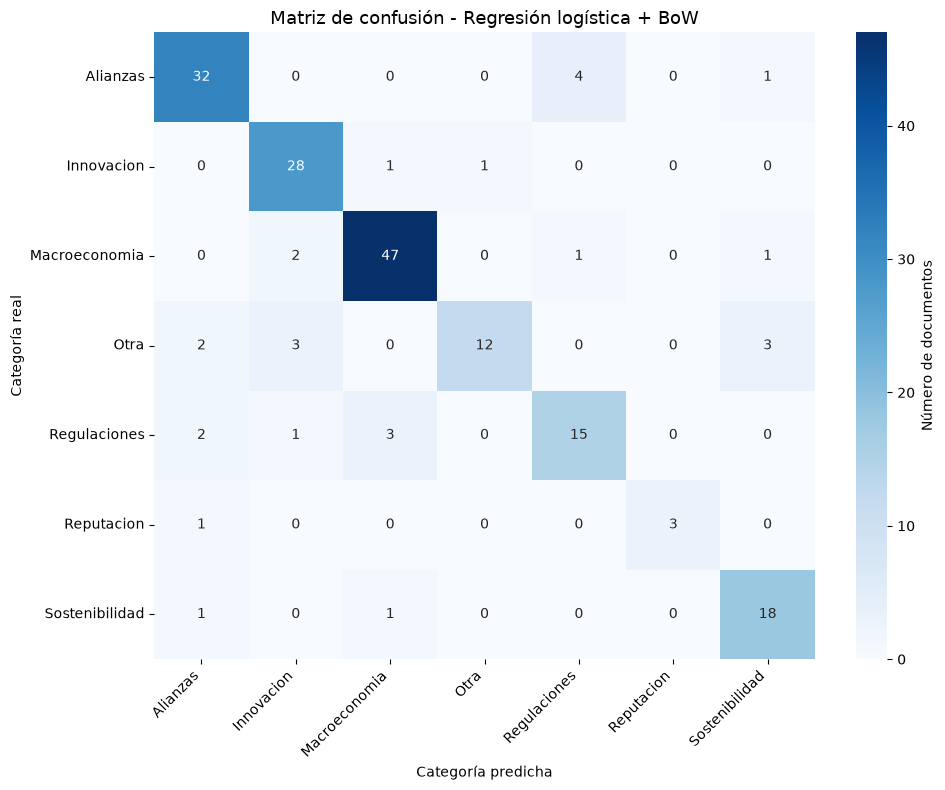

In [110]:
# 2.6 Matriz de confusión - Regresión logística + BoW


# Mantener el mismo orden de categorías en filas y columnas
categorias_logistica = sorted(y.unique())

# Calcular la matriz de confusión
cm_log_bow = confusion_matrix(
    y_val,
    y_val_pred_log_bow,
    labels=categorias_logistica
)

# Crear la gráfica
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_log_bow,
    annot=True,                          # Mostrar valores dentro de las celdas
    fmt="d",                             # Mostrar valores enteros
    cmap="Blues",
    xticklabels=categorias_logistica,
    yticklabels=categorias_logistica,
    cbar_kws={"label": "Número de documentos"}
)

# Títulos y etiquetas
plt.title(
    "Matriz de confusión - Regresión logística + BoW",
    fontsize=13
)

plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")

# Mejorar la lectura de las categorías
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [109]:
# 2.5 Classification Report - Regresión logística + TF-IDF


# Generar el reporte como diccionario
reporte_tfidf = classification_report(
    y_val,
    y_val_pred_log_tfidf,
    output_dict=True,
    zero_division=0
)

# Convertir el reporte a DataFrame
df_reporte_tfidf = pd.DataFrame(
    reporte_tfidf
).transpose()

# Redondear métricas para facilitar la lectura
df_reporte_tfidf = df_reporte_tfidf.round(4)

print("Classification Report - Regresión logística + TF-IDF")
display(df_reporte_tfidf)

Classification Report - Regresión logística + TF-IDF


,precision,recall,f1-score,support
Alianzas,0.6809,0.8649,0.7619,37.0000
Innovacion,0.8056,0.9667,0.8788,30.0000
Macroeconomia,0.8679,0.9020,0.8846,51.0000
Otra,0.8889,0.4000,0.5517,20.0000
Regulaciones,0.8125,0.6190,0.7027,21.0000
Reputacion,0.0000,0.0000,0.0000,4.0000
Sostenibilidad,0.7273,0.8000,0.7619,20.0000
accuracy,0.7869,0.7869,0.7869,0.7869
macro avg,0.6833,0.6504,0.6488,183.0000
weighted avg,0.7815,0.7869,0.7688,183.0000


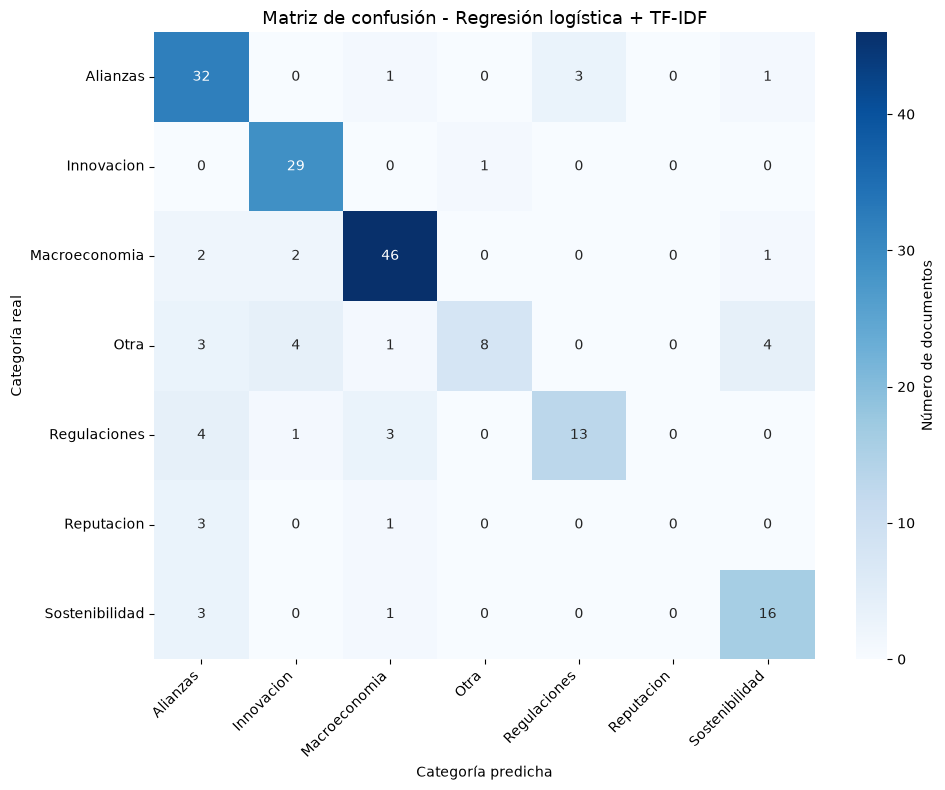

In [108]:

# 2.7 Matriz de confusión - Regresión logística + TF-IDF


cm_log_tfidf = confusion_matrix(
    y_val,
    y_val_pred_log_tfidf,
    labels=categorias_logistica
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_log_tfidf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=categorias_logistica,
    yticklabels=categorias_logistica,
    cbar_kws={"label": "Número de documentos"}
)

plt.title(
    "Matriz de confusión - Regresión logística + TF-IDF",
    fontsize=13
)

plt.xlabel("Categoría predicha")
plt.ylabel("Categoría real")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [101]:

# Comparación de entrenamiento vs. validación


resultados_logistica[
    [
        "Modelo",
        "Conjunto",
        "Accuracy",
        "F1 macro",
        "F1 ponderado"
    ]
]

,Modelo,Conjunto,Accuracy,F1 macro,F1 ponderado
0,Regresión logística + BoW,Entrenamiento,0.9965,0.9966,0.9965
1,Regresión logística + BoW,Validación,0.8470,0.8278,0.8440
2,Regresión logística + TF-IDF,Entrenamiento,0.9495,0.8957,0.9464
3,Regresión logística + TF-IDF,Validación,0.7869,0.6488,0.7688


### ¿Hay indicios de overfitting? ¿El modelo generaliza correctamente?

Sí, se observan indicios de **overfitting** en ambos modelos porque el desempeño disminuye al pasar de entrenamiento a validación.

Con **BoW**, el accuracy pasó de **0.9965 en entrenamiento a 0.8470 en validación**, mientras que el F1 macro disminuyó de **0.9966 a 0.8278**. Esto muestra que el modelo aprende muy bien los datos de entrenamiento, pero pierde rendimiento cuando recibe documentos que no había visto.

Con **TF-IDF** también ocurre una disminución: el accuracy pasó de **0.9495 a 0.7869** y el F1 macro de **0.8957 a 0.6488**.

Por lo tanto, ambos modelos presentan una diferencia entre entrenamiento y validación, aunque **BoW mantiene mejores resultados sobre datos nuevos** y muestra una mejor capacidad de generalización.

### Comparación entre BoW y TF-IDF
### ¿Cuál representación obtuvo mejor desempeño: BoW o TF-IDF? ¿Por qué?

La representación **BoW obtuvo el mejor desempeño** con regresión logística. En validación alcanzó un accuracy de **0.8470**, un F1 macro de **0.8278** y un F1 ponderado de **0.8440**. Por otro lado, TF-IDF obtuvo **0.7869** de accuracy, **0.6488** de F1 macro y **0.7688** de F1 ponderado.

La diferencia también se observa por categoría. Por ejemplo, con BoW la categoría **Reputación** obtuvo un recall de **0.75**, mientras que con TF-IDF ninguno de sus cuatro documentos de validación fue clasificado correctamente.

En este corpus, los conteos directos de palabras de **BoW** parecen proporcionar mejores señales para separar las categorías. TF-IDF reduce la importancia de palabras frecuentes y, en este caso, algunas de esas palabras también pueden aportar información útil para la clasificación.

In [102]:

# 3. Interpretación de pesos
# 3.1 Inspeccionar coeficientes


print("Categorías del modelo:")
print(modelo_logistico_bow.classes_)

print("\nForma de coef_:")
print(modelo_logistico_bow.coef_.shape)

print("\nTamaño del vocabulario:")
print(len(bow_vectorizer.get_feature_names_out()))

Categorías del modelo:
['Alianzas' 'Innovacion' 'Macroeconomia' 'Otra' 'Regulaciones'
 'Reputacion' 'Sostenibilidad']

Forma de coef_:
(7, 18239)

Tamaño del vocabulario:
18239


In [103]:

# Función para obtener palabras con mayor peso
# positivo y negativo


def palabras_por_peso(modelo, vectorizer, categoria, n=15):

    # Vocabulario utilizado por el modelo
    vocabulario = vectorizer.get_feature_names_out()

    # Encontrar la fila correspondiente a la categoría
    indice_categoria = list(modelo.classes_).index(categoria)

    # Pesos aprendidos para esa categoría
    pesos = modelo.coef_[indice_categoria]

    # 15 pesos más positivos
    indices_positivos = np.argsort(pesos)[::-1][:n]

    # 15 pesos más negativos
    indices_negativos = np.argsort(pesos)[:n]

    positivos = pd.DataFrame({
        "Palabra": vocabulario[indices_positivos],
        "Peso": pesos[indices_positivos]
    })

    negativos = pd.DataFrame({
        "Palabra": vocabulario[indices_negativos],
        "Peso": pesos[indices_negativos]
    })

    return positivos, negativos

In [107]:
# Pesos positivos y negativos por categoría


categorias_pesos = [
    "Macroeconomia",
    "Innovacion",
    "Sostenibilidad"
]

resultados_pesos = {}

for categoria in categorias_pesos:

    # Obtener las 15 palabras con mayor peso positivo y negativo
    positivos, negativos = palabras_por_peso(
        modelo_logistico_bow,
        bow_vectorizer,
        categoria,
        n=15
    )

    # Guardar resultados para utilizarlos posteriormente
    resultados_pesos[categoria] = {
        "positivos": positivos,
        "negativos": negativos
    }

    # Crear una tabla comparativa
    comparacion_pesos = pd.DataFrame({
        "Palabra a favor": positivos["Palabra"].values,
        "Peso positivo": positivos["Peso"].values,
        "Palabra en contra": negativos["Palabra"].values,
        "Peso negativo": negativos["Peso"].values
    })

    # Redondear los pesos para facilitar la lectura
    comparacion_pesos["Peso positivo"] = (
        comparacion_pesos["Peso positivo"].round(4)
    )

    comparacion_pesos["Peso negativo"] = (
        comparacion_pesos["Peso negativo"].round(4)
    )

    print("\n" + "=" * 70)
    print(f"PESOS DE LA CATEGORÍA: {categoria}")
    print("=" * 70)

    display(comparacion_pesos)


PESOS DE LA CATEGORÍA: Macroeconomia


,Palabra a favor,Peso positivo,Palabra en contra,Peso negativo
0,inflación,0.4965,digital,-0.2415
1,aumento,0.2667,buscar,-0.2307
2,precio,0.2488,alianza,-0.2268
3,2022,0.2472,persona,-0.2182
4,2023,0.2437,contar,-0.2128
5,consumidor,0.2169,hacer,-0.2035
6,economía,0.2069,compañía,-0.2030
7,publicado,0.2031,usuario,-0.1967
8,económico,0.2025,colombia,-0.1858
9,españa,0.2018,financiero,-0.1767



PESOS DE LA CATEGORÍA: Innovacion


,Palabra a favor,Peso positivo,Palabra en contra,Peso negativo
0,bbva,0.6073,colombia,-0.3180
1,capital,0.3311,país,-0.2694
2,innovación,0.2789,sostenible,-0.2456
3,finanza,0.2702,estrategia,-0.2230
4,perfil,0.2565,decir,-0.2186
5,cuenta,0.2420,alianza,-0.1973
6,talento,0.2307,director,-0.1961
7,spark,0.2247,además,-0.1896
8,inversor,0.2180,manera,-0.1836
9,design,0.2124,servicio,-0.1682



PESOS DE LA CATEGORÍA: Sostenibilidad


,Palabra a favor,Peso positivo,Palabra en contra,Peso negativo
0,sostenible,0.4546,colombia,-0.2439
1,podcast,0.2721,decir,-0.2103
2,ayudar,0.2297,presidente,-0.1854
3,sostenibilidad,0.2158,compañía,-0.1513
4,climático,0.2156,servicio,-0.1488
5,responsable,0.2141,hacer,-0.1407
6,verde,0.2060,seguir,-0.1381
7,transición,0.1818,mercado,-0.1359
8,planeta,0.1810,empresa,-0.1328
9,eléctrico,0.1793,alianza,-0.1299


In [106]:

# Comparación: Regresión Logística vs. Naive Bayes


for categoria in categorias_pesos:

    # Obtener palabras con mayor peso positivo de Regresión Logística
    positivos_log = resultados_pesos[categoria]["positivos"].copy()

    # Obtener palabras con mayor P(w|c) de Naive Bayes
    top_nb = top_palabras_por_categoria(
        modelo_bow,
        bow_vectorizer,
        categorias_modelo,
        categoria,
        n=15
    ).copy()

    # Renombrar columnas para facilitar la comparación
    positivos_log = positivos_log.rename(
        columns={"Peso": "Peso Logístico"}
    )

    top_nb = top_nb.rename(
        columns={"P(w|c)": "P(w|c) Naive Bayes"}
    )

    # Unir ambas listas por posición
    comparacion = pd.DataFrame({
        "Regresión logística": positivos_log["Palabra"].values,
        "Peso logístico": positivos_log["Peso Logístico"].values,
        "Naive Bayes": top_nb["Palabra"].values,
        "P(w|c)": top_nb["P(w|c) Naive Bayes"].values
    })

    print("\n" + "=" * 75)
    print(f"COMPARACIÓN DE MODELOS - {categoria}")
    print("=" * 75)

    display(comparacion)


COMPARACIÓN DE MODELOS - Macroeconomia


,Regresión logística,Peso logístico,Naive Bayes,P(w|c)
0,inflación,0.496496,inflación,0.010726
1,aumento,0.266745,año,0.008000
2,precio,0.248810,precio,0.007731
3,2022,0.247176,poder,0.005965
4,2023,0.243701,bbva,0.004690
5,consumidor,0.216895,país,0.004398
6,economía,0.206919,él,0.004363
7,publicado,0.203122,mes,0.004304
8,económico,0.202499,mayor,0.004258
9,españa,0.201803,tasa,0.004164



COMPARACIÓN DE MODELOS - Innovacion


,Regresión logística,Peso logístico,Naive Bayes,P(w|c)
0,bbva,0.607284,bbva,0.013295
1,capital,0.331053,poder,0.006596
2,innovación,0.278899,él,0.004999
3,finanza,0.270181,cliente,0.004842
4,perfil,0.256531,banco,0.004565
5,cuenta,0.242018,nuevo,0.004339
6,talento,0.230674,digital,0.004235
7,spark,0.224721,permitir,0.004061
8,inversor,0.217992,empresa,0.003888
9,design,0.212423,financiero,0.003714



COMPARACIÓN DE MODELOS - Sostenibilidad


,Regresión logística,Peso logístico,Naive Bayes,P(w|c)
0,sostenible,0.454568,bbva,0.006179
1,podcast,0.272064,él,0.005296
2,ayudar,0.229675,poder,0.005180
3,sostenibilidad,0.215763,sostenible,0.004747
4,climático,0.215584,energía,0.003481
5,responsable,0.214134,sostenibilidad,0.003131
6,verde,0.205976,objetivo,0.003031
7,transición,0.181845,agua,0.002981
8,planeta,0.181010,año,0.002848
9,eléctrico,0.179345,cambio,0.002565


### ¿Tienen sentido esas palabras como evidencia a favor o en contra de cada categoría?

Sí. En Macroeconomía aparecen palabras como *inflación*, *precio*, *economía* e *IPC*. En Innovación aparecen *innovación*, *tecnología*, *capital* y *talento*. En Sostenibilidad destacan *sostenible*, *climático*, *verde* y *medioambiental*. En general, los pesos positivos sí representan temas relacionados con cada categoría.

Los pesos negativos se pueden interpretar como evidencia en contra de una categoría, ya que su presencia disminuye el puntaje que la regresión logística asigna a esa clase.

### ¿Coinciden estas palabras con las de mayor P(wᵢ|c) de Naive Bayes? ¿Qué diferencias encuentra y a qué las atribuye?

Coinciden en algunas palabras, pero no completamente. Por ejemplo, en Macroeconomía ambos modelos destacan *inflación* y *precio*, mientras que en Sostenibilidad coinciden en *sostenible* y *climático*.

La diferencia se debe a que Naive Bayes calcula la probabilidad de cada palabra dentro de una categoría según sus frecuencias, mientras que la regresión logística aprende los pesos de las palabras de forma conjunta buscando separar mejor unas categorías de otras.

## 4. Comparación con Naive Bayes

En esta sección se comparan los modelos obtenidos en el Laboratorio 3
con los modelos de regresión logística de este laboratorio.

Se comparan cuatro combinaciones:

- Naive Bayes + BoW
- Naive Bayes + TF-IDF
- Regresión logística + BoW
- Regresión logística + TF-IDF

La comparación se realiza utilizando accuracy, F1 macro, F1 ponderado y
tiempo de entrenamiento.

In [115]:

# 4.1 Tabla comparativa: Naive Bayes vs. Regresión logística


comparacion_modelos = pd.DataFrame([
    {
        "Modelo": "Naive Bayes",
        "Representación": "BoW",
        "Accuracy": accuracy_score(
            y_val,
            y_val_pred_bow
        ),
        "F1 macro": f1_score(
            y_val,
            y_val_pred_bow,
            average="macro",
            zero_division=0
        ),
        "F1 ponderado": f1_score(
            y_val,
            y_val_pred_bow,
            average="weighted",
            zero_division=0
        ),
        "Tiempo entrenamiento (s)": tiempo_entrenamiento_nb_bow
    },
    {
        "Modelo": "Naive Bayes",
        "Representación": "TF-IDF",
        "Accuracy": accuracy_score(
            y_val,
            y_val_pred_tfidf
        ),
        "F1 macro": f1_score(
            y_val,
            y_val_pred_tfidf,
            average="macro",
            zero_division=0
        ),
        "F1 ponderado": f1_score(
            y_val,
            y_val_pred_tfidf,
            average="weighted",
            zero_division=0
        ),
        "Tiempo entrenamiento (s)": tiempo_entrenamiento_nb_tfidf
    },
    {
        "Modelo": "Regresión logística",
        "Representación": "BoW",
        "Accuracy": accuracy_score(
            y_val,
            y_val_pred_log_bow
        ),
        "F1 macro": f1_score(
            y_val,
            y_val_pred_log_bow,
            average="macro",
            zero_division=0
        ),
        "F1 ponderado": f1_score(
            y_val,
            y_val_pred_log_bow,
            average="weighted",
            zero_division=0
        ),
        "Tiempo entrenamiento (s)": tiempo_entrenamiento_logistico_bow
    },
    {
        "Modelo": "Regresión logística",
        "Representación": "TF-IDF",
        "Accuracy": accuracy_score(
            y_val,
            y_val_pred_log_tfidf
        ),
        "F1 macro": f1_score(
            y_val,
            y_val_pred_log_tfidf,
            average="macro",
            zero_division=0
        ),
        "F1 ponderado": f1_score(
            y_val,
            y_val_pred_log_tfidf,
            average="weighted",
            zero_division=0
        ),
        "Tiempo entrenamiento (s)": tiempo_entrenamiento_logistico_tfidf
    }
])

# Redondear resultados
columnas_numericas = [
    "Accuracy",
    "F1 macro",
    "F1 ponderado",
    "Tiempo entrenamiento (s)"
]

comparacion_modelos[columnas_numericas] = (
    comparacion_modelos[columnas_numericas]
    .round(4)
)

comparacion_modelos

,Modelo,Representación,Accuracy,F1 macro,F1 ponderado,Tiempo entrenamiento (s)
0,Naive Bayes,BoW,0.8142,0.7389,0.8042,0.0159
1,Naive Bayes,TF-IDF,0.5792,0.3751,0.5023,0.0163
2,Regresión logística,BoW,0.8470,0.8278,0.8440,0.8765
3,Regresión logística,TF-IDF,0.7869,0.6488,0.7688,0.3511


### ¿Qué modelo obtuvo mejor desempeño? ¿La diferencia es grande o marginal?

El modelo con mejor desempeño fue **Regresión logística + BoW**, con un accuracy de **0.8470**, un F1 macro de **0.8278** y un F1 ponderado de **0.8440**.

Naive Bayes + BoW obtuvo un accuracy de **0.8142** y un F1 macro de **0.7389**. La diferencia en accuracy es relativamente pequeña, de aproximadamente 3 puntos porcentuales, pero la diferencia en F1 macro es mayor. Esto indica que la regresión logística tuvo un comportamiento más equilibrado entre las diferentes categorías.

Sin embargo, Naive Bayes fue considerablemente más rápido de entrenar: aproximadamente **0.016 segundos**, frente a **0.88 segundos** de la regresión logística con BoW.

### ¿Cómo se relacionan estos resultados con la forma en que cada modelo aprende sus pesos?

Naive Bayes calcula **P(wᵢ|c)** para cada palabra a partir de sus frecuencias y supone independencia condicional entre las palabras.

La regresión logística, en cambio, aprende los pesos de todas las características de forma conjunta buscando separar directamente las categorías. Esto puede ayudar a reducir la importancia de palabras frecuentes pero poco discriminativas y aumentar el peso de términos que permiten distinguir mejor una categoría de otra.

En nuestros resultados, esta diferencia puede explicar por qué la regresión logística obtuvo un mejor F1 macro que Naive Bayes, aunque necesitó más tiempo de entrenamiento.

In [116]:

# 5.1 Identificar las confusiones más frecuentes
# Regresión logística + BoW


# Copiar la matriz de confusión para no modificar la original
cm_errores_log = cm_log_bow.copy()

# Eliminar los aciertos de la diagonal
np.fill_diagonal(cm_errores_log, 0)

# Guardar todas las confusiones encontradas
confusiones_log = []

for i in range(len(categorias_logistica)):
    for j in range(len(categorias_logistica)):

        if i != j and cm_errores_log[i, j] > 0:

            confusiones_log.append({
                "Categoría real": categorias_logistica[i],
                "Categoría predicha": categorias_logistica[j],
                "Errores": cm_errores_log[i, j]
            })

# Convertir a DataFrame y ordenar de mayor a menor
df_confusiones_log = (
    pd.DataFrame(confusiones_log)
    .sort_values(
        "Errores",
        ascending=False
    )
    .reset_index(drop=True)
)

# Mostrar las 10 confusiones más frecuentes
df_confusiones_log.head(10)

,Categoría real,Categoría predicha,Errores
0,Alianzas,Regulaciones,4
1,Otra,Innovacion,3
2,Otra,Sostenibilidad,3
3,Regulaciones,Macroeconomia,3
4,Macroeconomia,Innovacion,2
5,Otra,Alianzas,2
6,Regulaciones,Alianzas,2
7,Alianzas,Sostenibilidad,1
8,Innovacion,Macroeconomia,1
9,Innovacion,Otra,1


In [120]:

# 5.2 Documentos mal clasificados
# Alianzas -> Regulaciones


# Crear DataFrame con los resultados de validación
df_errores_log = pd.DataFrame({
    "Texto": X_val,
    "Categoría real": y_val,
    "Categoría predicha": y_val_pred_log_bow
}).reset_index()

df_errores_log = df_errores_log.rename(
    columns={"index": "Índice"}
)

# Filtrar la confusión más frecuente
errores_alianzas_regulaciones = df_errores_log[
    (df_errores_log["Categoría real"] == "Regulaciones") &
    (df_errores_log["Categoría predicha"] == "Macroeconomia")
]

errores_alianzas_regulaciones[
    [
        "Índice",
        "Categoría real",
        "Categoría predicha",
        "Texto"
    ]
]

,Índice,Categoría real,Categoría predicha,Texto
0,310,Regulaciones,Macroeconomia,aunque año completo actividad económico visto ...
35,229,Regulaciones,Macroeconomia,entrevista publicado miércoles financial tim p...
172,196,Regulaciones,Macroeconomia,inflación venezuela marzo continuar desacelera...
